# **Youtube Video Views Prediction**

#### Current model situation (Before rewrite)

1. MAE (Mean Absolute Error): 670,593.83
- This number seems quite large, but its interpretation depends on your data's scale. If you're predicting something like house prices or company revenues where values are in millions, this might be acceptable.

2. RMSE (Root Mean Square Error): 3,197,034.17
- This is significantly higher than the MAE, which indicates you have some large prediction errors (outliers) since RMSE penalizes large errors more heavily.

3. MAPE (Mean Absolute Percentage Error): 59.31%
- This is concerning. A MAPE of ~59% means your predictions are off by about 59% on average. Generally, a MAPE above 20% is considered poor for most applications.

4. R² Scores:
- Test: 0.093 (9.3%)
- Cross-validation train: 0.925 (92.5%)
- Cross-validation test: 0.712 (71.2%)

The most concerning aspects are:

1. The huge gap between training (92.5%) and test (9.3%) R² scores indicates severe overfitting
2. The final test R² of 0.093 means your model only explains about 9.3% of the variance in the target variable, which is very poor
3. The MAPE of 59% suggests low prediction accuracy

> Will need to initialize rewrite for this project

## 📌 Problem Statement  

A digital media analytics company in India aims to forecast YouTube video performance to support content creators and marketers in optimizing their content strategies. However, the current approach lacks predictive capabilities, making it challenging to estimate the potential success of a video before publishing. This results in missed opportunities for maximizing audience engagement and leveraging trends effectively.  

## 📌 Goals  

- Predict YouTube video performance: Develop a machine learning model to forecast the number of views a video might generate before it is uploaded. (**MAIN**)  
- Assist content creators and marketers: Enable data-driven decisions in content planning and optimization. (**SECONDARY**)  

## 📌 Objectives  

The project seeks to achieve the following objectives:  

1. Build a predictive model capable of estimating the number of views a video will generate, leveraging historical data and video metadata.  
2. Identify key features influencing viewership trends to provide actionable insights for video optimization.  
3. Help creators and marketers align their strategies with emerging trends and maximize audience reach.  

## 📌 Business Metrics  

- **Mean Absolute Percentage Error (MAPE):** Measure the accuracy of the predicted view count compared to the actual view count. (**MAIN**)  
- **Engagement Rate (ER):** Percentage of interactions (likes, comments, shares) relative to the video views to gauge engagement potential. (**SECONDARY**)  

# **STAGE 1 : EXPLORATORY DATA ANALYSIS (EDA)**

## Project Setup

In [1]:
import os
from pathlib import Path

# Change working directory (for I/O operations)
os.chdir(Path.cwd())

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

### Specific for Google Colab

In [ ]:
# # Check if running in Google Colab
# import sys
# IN_COLAB = 'google.colab' in sys.modules

# if IN_COLAB:
#     # Install uv package manager
#     !pip install uv

#     # Install dependencies
#     !uv pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost category-encoders joblib ipykernel gradio openpyxl deep-translator tenacity tqdm langid

#     # # Mount Google Drive (if data is stored there)
#     # from google.colab import drive
#     # drive.mount('/content/drive')

#     # Option 1: Load from Google Drive
#     # df_raw = pd.read_excel('/content/drive/MyDrive/path/to/youtube_statistics.xlsx')

#     # Option 2: Upload file directly
#     from google.colab import files
#     uploaded = files.upload()  # This will prompt you to upload the file

#     # Import libraries
#     import pandas as pd
#     import numpy as np
#     import matplotlib.pyplot as plt
#     import seaborn as sns

#     import warnings
#     warnings.filterwarnings('ignore')

#     # Settings
#     sns.set_style('darkgrid')
#     pd.set_option('display.max_columns', None)

#     df_raw = pd.read_excel('youtube_statistics.xlsx')

#     # Option 3: Load from URL (if hosted online)
#     # df_raw = pd.read_excel('https://your-url.com/youtube_statistics.xlsx')

#     # Create a copy of the dataframe
#     df = df_raw.copy()
#     display(df)

## Data Understanding & Initial Transformation

In [ ]:
# Read data
df_raw = pd.read_excel('data/youtube_statistics.xlsx')

# Create a copy of the dataframe
df = df_raw.copy()
display(df)

,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,publish_date
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,12:20:39,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15,920,81,2017-11-12
1,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,05:43:56,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",19,2232,58,2017-11-13
2,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,15:48:08,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,14,482,58,2017-11-12
3,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,07:08:48,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False,This video showcases the difference between pe...,20,263,30,2017-11-12
4,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,01:14:16,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,11,753,88,2017-11-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2018-06-14,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,08:01:11,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...,19,818,100,2018-06-13
36787,2018-06-14,Seetha | Flowers | Ep# 364,Flowers TV,24,11:30:04,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",8,468,26,2018-06-13
36788,2018-06-14,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,05:00:02,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,False,False,False,Subscribe to Mazhavil Manorama now for your da...,8,2187,57,2018-06-13
36789,2018-06-14,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,15:07:49,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,False,False,False,Nuabohu : Story of a rustic village girl who w...,15,432,64,2018-06-13


In [5]:
# Check data information using utility function
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,trending_date,object,0,0.00,0,0.00,0,0.0,0,0,4229,205,0.0056,"2017-11-14, 2017-11-15, 2017-11-16, 2017-11-17..."
1,title,object,0,0.00,0,0.00,0,0.0,0,0,4229,16431,0.4466,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...
2,channel_title,object,0,0.00,0,0.00,0,0.0,0,0,4229,1390,0.0378,"Lokdhun Punjabi, HJ NEWS, TFPC, Eruma Saani, F..."
3,category_id,int64,0,0.00,0,0.00,0,0.0,0,0,4229,17,0.0005,"1, 25, 24, 23, 10"
4,publish_time,object,0,0.00,0,0.00,0,0.0,0,0,4229,12375,0.3364,"12:20:39, 05:43:56, 15:48:08, 07:08:48, 01:14:16"
5,tags,object,0,0.00,0,0.00,0,0.0,0,0,4229,12463,0.3388,"sharry mann|""sharry mann new song""|""sharry man..."
6,views,int64,0,0.00,0,0.00,0,0.0,0,0,4229,31638,0.8599,"1096327, 590101, 473988, 1242680, 464015"
7,likes,int64,0,0.00,757,2.06,0,0.0,0,0,4229,15473,0.4206,"33966, 735, 2011, 70353, 492"
8,dislikes,int64,0,0.00,766,2.08,0,0.0,0,0,4229,5072,0.1379,"798, 904, 243, 1624, 293"
9,comment_count,int64,0,0.00,1294,3.52,0,0.0,0,0,4229,6024,0.1637,"882, 0, 149, 2684, 66"


In [6]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns {df.shape[1]}')

Number of rows: 36791
Number of columns 18


**Quick Overview:**
- Dataset contains 36791 rows, 18 features.
- There are several columns that will be dropped for our analysis.
- Dataset consists of 4 data types; float64, int64, datetime, and object. With several columns that currently has object type need to be transformed into datetime columns (more on this below).
- Dataset contains null values only in `description` column with really small percentage. But in this case the null values in `description` column just means that the videos doesn't have a description so we don't have to drop them.

**Feature Information**

| **Feature Name** | **Description** | **Data Type** | **Specific Data Type** |
|-----------------|-----------------|---------------|----------------------|
| `trending_date` | Date when the video is trending | Date | Timestamp |
| `title` | Video title | Text | String |
| `channel_title` | Channel name | Text | String |
| `category_id` | Video category in label encoding | Numerical | Integer (Categorical) |
| `publish_time` | Video publishing time | Time | Timestamp |
| `tags` | Tags used in the video | Text | String (Array) |
| `views` | Number of video views **(Target Variable)** | Numerical | Integer (Discrete) |
| `likes` | Number of video likes | Numerical | Integer (Discrete) |
| `dislikes` | Number of video dislikes | Numerical | Integer (Discrete) |
| `comment_count` | Number of comments on the video | Numerical | Integer (Discrete) |
| `comments_disabled` | Indicates whether comments are disabled for the video | Boolean | Binary |
| `ratings_disabled` | Indicates whether ratings are disabled for the video | Boolean | Binary |
| `video_error_or_removed` | Indicates whether the video is currently in error or has been removed | Boolean | Binary |
| `description` | Video description | Text | String |
| `No_tags` | Number of tags used | Numerical | Integer (Discrete) |
| `desc_len` | Length of the video description in terms of words | Numerical | Integer (Discrete) |
| `len_title` | Length of the video title in terms of words | Numerical | Integer (Discrete) |
| `publish_date` | Date when the video was published | Date | Timestamp |

In [7]:
# Grouping columns based on their types
nums_cols = ['likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'len_title', 'views']
cats_cols = ['title', 'channel_title', 'tags','description', 'category_id', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']
dates_cols = ['trending_date', 'publish_time_fixed']

---
Just from these information, there are some useful insight to this data that understanding it could make it easier for further analysis and feature transformation, they are :

- The publish time information is currently separated here into 2 different columns, `publish_date` which already have the correct data type and `publish_time` that currently have object data type. We probably need to and then combine these 2 into 1 as a complete datetime format. Also, to get better insight we need to calculate the date difference between the new combined publish time and the `trending_date` (we can only do this in date since the `trending_date` granuality is limited to days).

- Video category (`category_id`) is displayed as a labelled number already, so we are quite unsure what the details of each video like which one is Gaming, Music Videos, News and Politics, etc.

- `title`, `tags`, and `description` are quite interesting to play around in text mining though it will be quite challenging in separating the english and indian texts (especially since I'm don't even know a single Indian word). So there's a high chance we will only be playing with the lenght of those text columns.

- As for boolean feature like `comments_disabled`, `ratings_disabled`, `video_error_or_removed` potentially could be encoded by one-hot encoding since they are nominal values.

- `channel_title` most likely if we want to use it, will be done through frequency/count encoding similar to other long text features.

- Feature `views` is the target variable, we would later move it to the last order in dataframe (personal preference).
---

Lastly, and probably the most important one is that in here we need to the context and flow of this problem. Since we get these features information after the videos are uploaded, so some features that is outside of our own initial control can't actually be used. For example `comments_count`, `video_error_or_removed`, etc. But this will be done later at feature selection section.

## Initial Transformation

In [8]:
# Re-arrange column (target 'views' at the end --> personal preference)
df = df[[col for col in df.columns if col != 'views'] + ['views']]

In [ ]:
# Combine publish time and publish date columns
df["publish_time_fixed"] = pd.to_datetime(df["publish_date"].astype(str) + " " + df["publish_time"].astype(str))
df.drop(columns=["publish_date", "publish_time"], inplace=True)

# Convert trending_date to datetime format
df['trending_date'] = pd.to_datetime(df['trending_date'])

# Change category id to categorical data type
df['category_id'] = df['category_id'].astype('str')

# Check the values of category_id
df["category_id"].value_counts().sort_values(ascending=False)

# Check the values of category_id with the most values
df.loc[df["category_id"] == "24"].sample(3)

> From that we could make hypothesis that the `category_id` of 24 is probably related to **movies/TV series**. We can try figure out the `category_id` name later using the wordcloud of `title`, `tags`, and `description` for each of them later in the data processing section.

### Translation Section

Since we have mixed language of Indian and English in our text features, we need to be able to solve this before going further into modelling later. There are several options to choose from, one is probably utilize the multilingual model but since this is probably complex, for now we will go with translating the data that contains Indian language into English.

In [1]:
# from utils import run_translation_pipeline

# # With language detection and export
# final_df = run_translation_pipeline(
#     df,
#     columns=['title', 'tags', 'description'],
#     export=True,
#     filename_prefix="youtube_data"
# )

---

# Starting Point 2 (EDA Continuation): After Initial Transformation on Text Columns

In [25]:
# Define data type mappings
dtype_mapping = {
    'category_id': str,
    'comments_disabled': str,
    'ratings_disabled': str,
    'video_error_or_removed': str
}

# Read the translated dataset with specified data types (This is done because CSV files don't preserve data type information)
df = pd.read_csv("data/youtube_data_translated.csv", dtype=dtype_mapping, parse_dates=['trending_date', 'publish_time_fixed'])

# Re-group columns based on their types
nums_cols = ['likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'len_title', 'views']
cats_cols = ['title', 'channel_title', 'tags','description', 'category_id', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']
dates_cols = ['trending_date', 'publish_time_fixed']

# Re-check the data
display(df.head(1))

# Re-check data information
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,trending_date,title,channel_title,category_id,tags,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,views,publish_time_fixed
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,"sharry mann|""sharry mann new song""|""sharry man...",33966,798,882,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15,920,81,1096327,2017-11-12 12:20:39


,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,trending_date,datetime64[us],0,0.00,0,0.00,0,0.0,0,0,4229,205,0.0056,"2017-11-14 00:00:00, 2017-11-15 00:00:00, 2017..."
1,title,str,0,0.00,0,0.00,0,0.0,0,0,4229,16421,0.4463,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...
2,channel_title,str,0,0.00,0,0.00,0,0.0,0,0,4229,1390,0.0378,"Lokdhun Punjabi, HJ NEWS, TFPC, Eruma Saani, F..."
3,category_id,str,0,0.00,0,0.00,0,0.0,0,36791,4229,17,0.0005,"1, 25, 24, 23, 10"
4,tags,str,0,0.00,0,0.00,0,0.0,0,0,4229,12465,0.3388,"sharry mann|""sharry mann new song""|""sharry man..."
5,likes,int64,0,0.00,757,2.06,0,0.0,0,0,4229,15473,0.4206,"33966, 735, 2011, 70353, 492"
6,dislikes,int64,0,0.00,766,2.08,0,0.0,0,0,4229,5072,0.1379,"798, 904, 243, 1624, 293"
7,comment_count,int64,0,0.00,1294,3.52,0,0.0,0,0,4229,6024,0.1637,"882, 0, 149, 2684, 66"
8,comments_disabled,str,0,0.00,0,0.00,0,0.0,0,0,4229,2,0.0001,"False, True"
9,ratings_disabled,str,0,0.00,0,0.00,0,0.0,0,0,4229,2,0.0001,"False, True"


The new translated version have duplicated values, we will need to handle those first.

In [26]:
# Handle duplicated rows
# Using drop_duplicates() with recommended parameters for clarity and control
df = df.drop_duplicates(keep='first', ignore_index=True)
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 32562


## Univariate Analysis

### Numerical Features

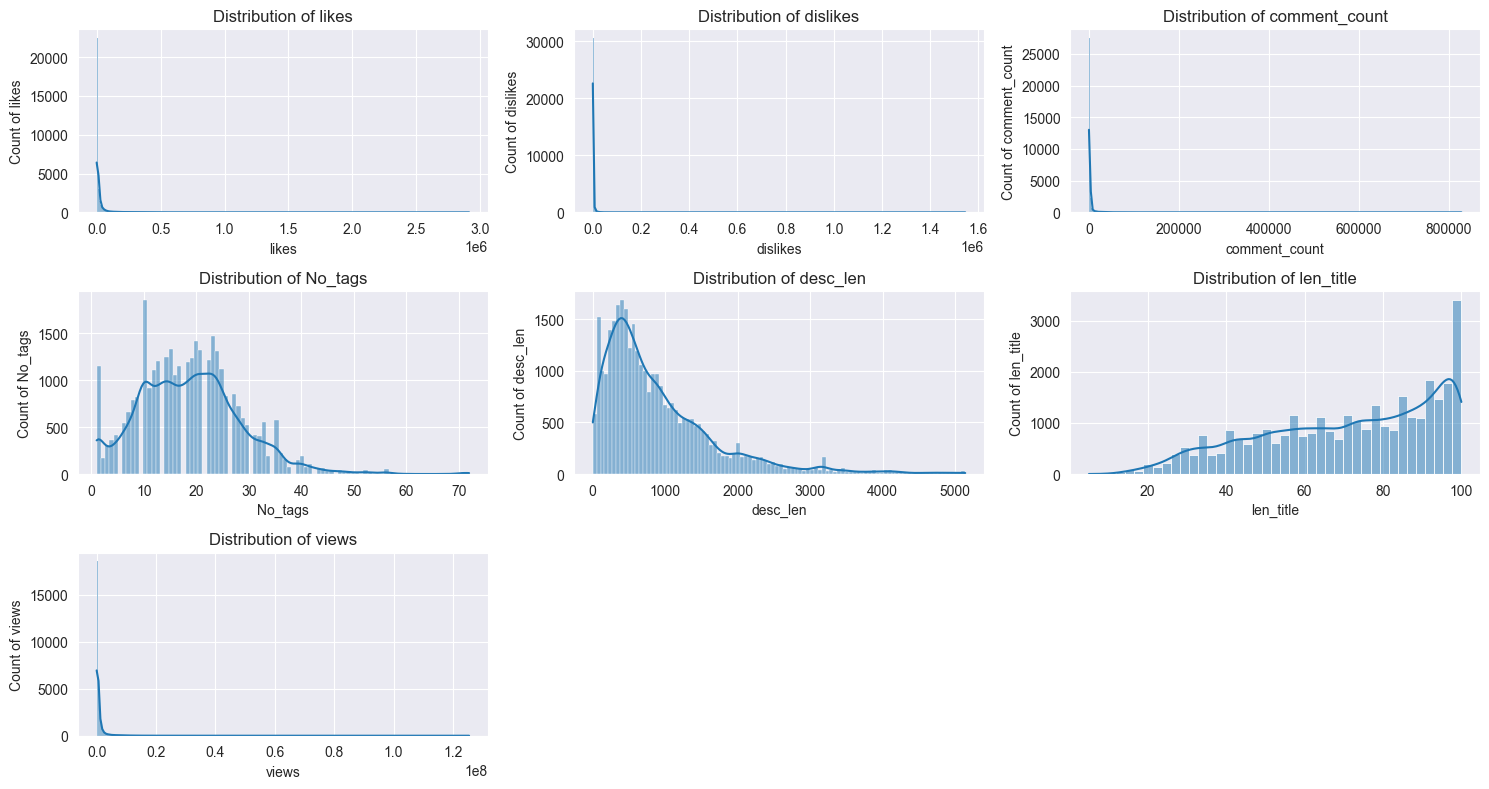

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,likes,32562.0,2.595444e+04,9.720113e+04,0.0,800.00,2817.0,12299.0,2912710.0,2912710.0,11499.00,374.506752,11.594982,215.857766
1,dislikes,32562.0,1.596781e+03,1.703103e+04,0.0,99.00,293.0,943.0,1545017.0,1545017.0,844.00,1066.585642,72.091587,5818.454424
2,comment_count,32562.0,2.561673e+03,1.488591e+04,0.0,74.00,306.0,1188.0,827755.0,827755.0,1114.00,581.101041,28.933575,1240.325657
3,No_tags,32562.0,1.884906e+01,9.863164e+00,1.0,12.00,19.0,25.0,72.0,71.0,13.00,52.327093,0.661132,1.347890
4,desc_len,32562.0,9.132707e+02,8.070886e+02,3.0,366.00,673.0,1226.0,5136.0,5133.0,860.00,88.373426,1.879880,4.503816
5,len_title,32562.0,7.099567e+01,2.228042e+01,5.0,54.00,75.0,91.0,100.0,95.0,37.00,31.382792,-0.477445,-0.865722
6,views,32562.0,1.007091e+06,3.171556e+06,4024.0,114162.25,277788.0,738924.5,125432237.0,125428213.0,624762.25,314.922381,12.942517,291.182111


,Column Name,Mean,Median,Mode,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,likes,25954.441,2817.0,0,11.595,215.858,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
1,dislikes,1596.781,293.0,0,72.092,5818.454,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
2,comment_count,2561.673,306.0,0,28.934,1240.326,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
3,No_tags,18.849,19.0,10,0.661,1.348,Moderately Positively Skewed,Leptokurtic (Heavy-tailed)
4,desc_len,913.271,673.0,295,1.880,4.504,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
5,len_title,70.996,75.0,100,-0.477,-0.866,Slightly Negatively Skewed,Platykurtic (Light-tailed)
6,views,1007091.465,277788.0,1682462,12.943,291.182,Highly Positively Skewed,Leptokurtic (Heavy-tailed)


In [9]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined, identify_distribution_types

plot_dynamic_hisplots_kdeplots(df=df, col_series=nums_cols, ncols=3, figsize=(15, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, nums_cols)
display(numerical_summary)

# Display the distribution types
result = identify_distribution_types(df, df.select_dtypes('number').columns.tolist())
display(result)

### Categorical Features

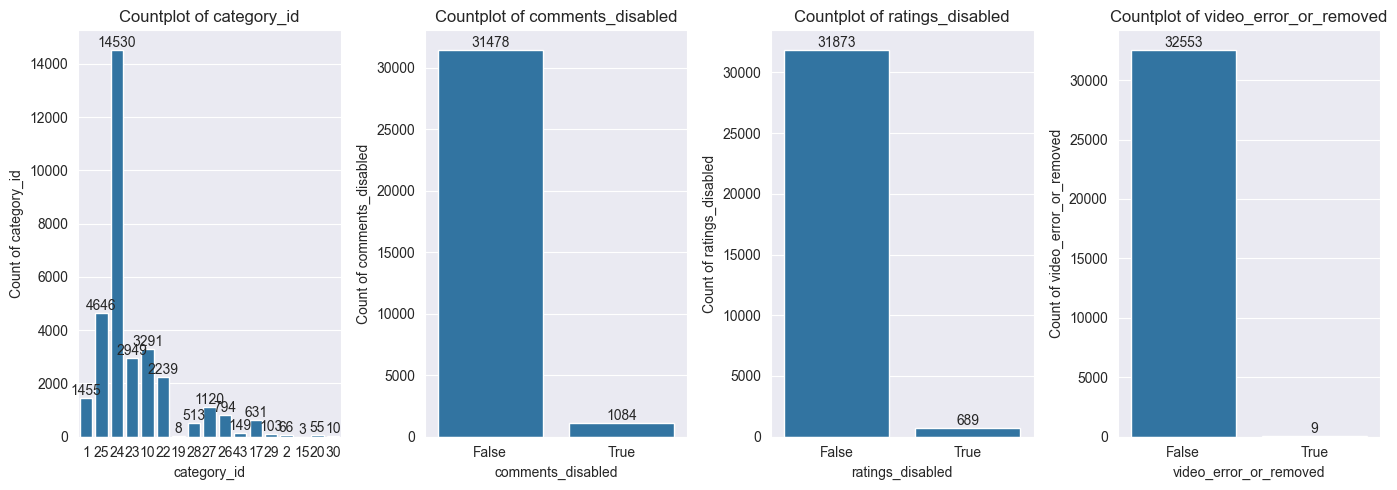

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,title,32562,16421,Nandhini | Today @ 9 pm | Sun TV,15,Daang ( Full Video ) | Mankirt Aulakh | Sukh S...,1,0.05,0.00,16421
1,channel_title,32562,1390,VikatanTV,208,Bollywood Sins,1,0.64,0.00,1390
2,tags,32562,12465,[none],1027,"Resnu desai|""actress renu desai""|""pawan kalyan...",1,3.15,0.00,12465
3,description,32518,13976,Subscribers Link: http://bit.ly/2qb69dZ\n\nCon...,150,Song - Daang\nSinger - Mankirt Aulakh\nFaceboo...,1,0.46,0.00,13976
4,category_id,32562,17,24,14530,15,3,44.62,0.01,17
5,comments_disabled,32562,2,False,31478,True,1084,96.67,3.33,2
6,ratings_disabled,32562,2,False,31873,True,689,97.88,2.12,2
7,video_error_or_removed,32562,2,False,32553,True,9,99.97,0.03,2


In [10]:
# Checking the distribution and statistical summary of categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Define categorical columns with few unique values for visualization
cats_few = ['category_id', 'comments_disabled',
    'ratings_disabled', 'video_error_or_removed']

plot_dynamic_countplot(df=df, col_series=cats_few, ncols=4, figsize=(14, 5))

# Display statistics for categorical columns
categorical_summary = describe_categorical_combined(df, cats_cols)
display(categorical_summary)

There is a significant imbalance in these boolean categorical values, so it will be addressed further, possibly through feature scaling later on if we want to keep them or just drop them altogether especially the `video_error_or_removed` column because of the extreme imbalance here.

### Date Features

In [11]:
from utils import describe_date_columns

# Analyze multiple date columns
describe_date_columns(df, dates_cols)

,count,mean,min,25%,50%,75%,max,date_range_days,date_range_months,date_range_years,unique_years,unique_months,unique_days,weekend_percentage,business_hours_percentage,most_common_month,most_common_weekday,max_gap_days,median_gap_days,future_dates_percentage,is_regular_interval
trending_date,32562,2018-02-19 02:17:53.300165,2017-11-14 00:00:00,2017-12-28 00:00:00,2018-02-14 00:00:00,2018-04-14 00:00:00,2018-06-14 00:00:00,212 days 00:00:00,7.066667,0.580822,2.0,8.0,205.0,29.924452,0.000000,12.0,Saturday,7.0,0.0,0.0,True
publish_time_fixed,32562,2018-02-17 10:41:19.559394,2017-05-27 20:27:30,2017-12-25 18:00:18.250000,2018-02-12 08:44:15,2018-04-12 16:00:27,2018-06-13 18:05:15,381 days 21:37:45,12.700000,1.043836,2.0,9.0,219.0,26.371230,54.483754,12.0,Friday,163.0,0.0,0.0,True


## Bivariate & Multivariate Analysis

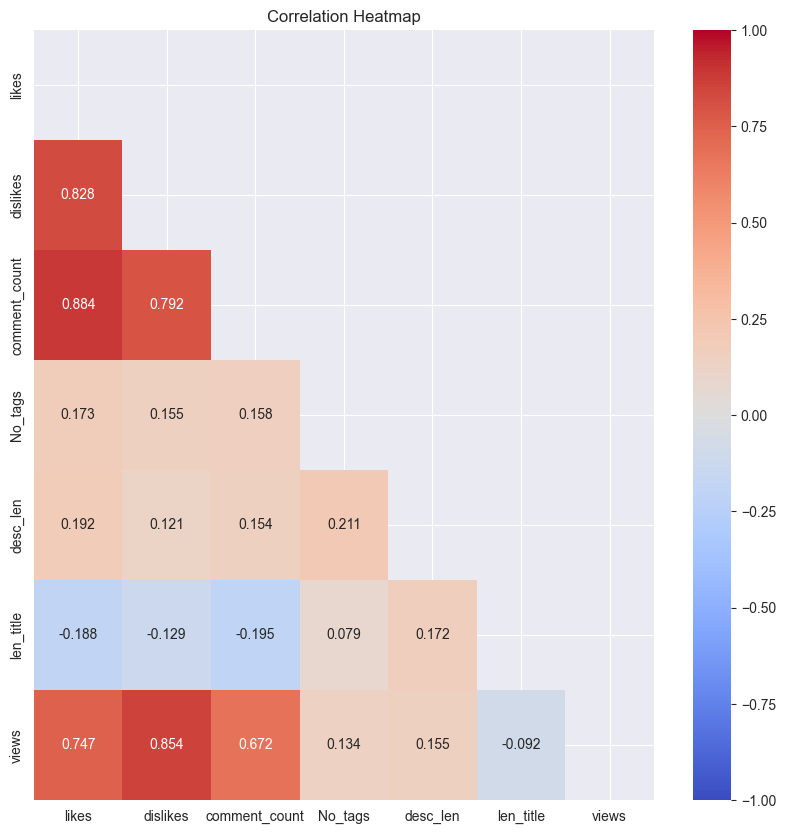

In [12]:
# Create a mask for the upper triangle
plt.figure(figsize=(10,10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

# Plot the heatmap
sns.heatmap(data = df.corr(numeric_only=True, method='spearman'), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# # Pairplot
# sns.pairplot(df, diag_kind='kde')
# plt.suptitle('Pairplot of Numerical Features')
# plt.tight_layout()
# plt.show()

## Text Columns Analysis

In [27]:
from utils.text_preprocessing import TextPreprocessor, TextVisualizer, quick_clean, get_text_stats

input_file = 'data/youtube_data_translated.csv'
output_file = 'data/youtube_data_text_preprocessed.csv'

# Display sample of raw text data
print("\nSample of raw text data:")
print("-"*40)
sample_cols = ['title', 'description', 'tags']
for col in sample_cols:
    if col in df.columns:
        print(f"\n{col.upper()} (first 3 samples):")
        for i, val in enumerate(df[col].head(3), 1):
            text = str(val)[:100] + "..." if len(str(val)) > 100 else str(val)
            print(f"  {i}. {text}")


Sample of raw text data:
----------------------------------------

TITLE (first 3 samples):
  1. Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November
  2. During periods, husband does this on stomach, you will be stunned to see
  3. Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC

DESCRIPTION (first 3 samples):
  1. Presenting Sharry Mann latest Punjabi Song  Cute Munda Teaser . The music of new punjabi song is giv...
  2. पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/...
  3. Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in,...

TAGS (first 3 samples):
  1. sharry mann|"sharry mann new song"|"sharry mann cute munda"|"sharry mann latest song"|"sharry mann p...
  2. During Periods
  3. Stylish Star Allu Arjun @ ChaySam Wedding Reception|"Stylish Star Allu Arjun"|"ChaySam Wedding Recep...


In [28]:
# Step 2: Calculate text statistics before preprocessing
print("\n" + "-"*80)
print("STEP 2: Text Statistics (Before Preprocessing)")
print("-"*80)
text_stats = get_text_stats(df, ['title', 'description', 'tags'])
print(text_stats.to_string(index=False))


--------------------------------------------------------------------------------
STEP 2: Text Statistics (Before Preprocessing)
--------------------------------------------------------------------------------
     column  total_documents  total_words  avg_words_per_doc  unique_words  avg_word_length
      title            32562       412164              12.66         31166             4.72
description            32518      3468869             106.68        146874             7.43
       tags            32562       852432              26.18        108205            11.22


In [29]:
# Step 3: Initialize TextPreprocessor
print("\n" + "-"*80)
print("STEP 3: Initializing TextPreprocessor")
print("-"*80)
preprocessor = TextPreprocessor(
    language='english',
    custom_stopwords={'youtube', 'video', 'watch', 'channel', 'subscribe'}
)
print(f"Stopwords count: {len(preprocessor._stopwords)}")
print(f"Language: {preprocessor.language}")


--------------------------------------------------------------------------------
STEP 3: Initializing TextPreprocessor
--------------------------------------------------------------------------------
Stopwords count: 203
Language: english


In [30]:
# Step 4: Apply text preprocessing
print("\n" + "-"*80)
print("STEP 4: Applying Text Preprocessing")
print("-"*80)

# Define preprocessing options
preprocessing_options = {
    'replace_newlines': True,
    'remove_html': True,
    'remove_urls': True,
    'remove_emails': True,
    'remove_social': True,  # Remove @mentions and #hashtags
    'expand_contractions': True,
    'remove_accents': True,
    'lowercase': True,
    'remove_special_chars': True,
    'keep_punctuation': False,
    'spell_correction': False,  # Disabled for speed
    'remove_stopwords': True,
    'lemmatize': True,
    'stem': False,  # Use lemmatization, not stemming
    'min_token_length': 2  # Remove single-character tokens
}

print("Preprocessing options:")
for key, value in preprocessing_options.items():
    print(f"  {key}: {value}")

# Apply preprocessing to text columns
text_columns = ['title', 'description', 'tags']
print(f"\nProcessing columns: {text_columns}")
print("This may take a moment for large datasets...")

df_processed = preprocessor.preprocess_dataframe(
    df, 
    columns=text_columns,
    options=preprocessing_options
)

print(f"\n✓ Preprocessing completed for {len(df_processed):,} rows")


--------------------------------------------------------------------------------
STEP 4: Applying Text Preprocessing
--------------------------------------------------------------------------------
Preprocessing options:
  replace_newlines: True
  remove_html: True
  remove_urls: True
  remove_emails: True
  remove_social: True
  expand_contractions: True
  remove_accents: True
  lowercase: True
  remove_special_chars: True
  keep_punctuation: False
  spell_correction: False
  remove_stopwords: True
  lemmatize: True
  stem: False
  min_token_length: 2

Processing columns: ['title', 'description', 'tags']
This may take a moment for large datasets...

✓ Preprocessing completed for 32,562 rows


In [31]:
# Step 5: Show before/after comparison
print("\n" + "-"*80)
print("STEP 5: Before/After Comparison")
print("-"*80)

for col in text_columns[:2]:  # Show first 2 columns
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print("  BEFORE:", str(df[col].iloc[0])[:100] + "...")
        print("  AFTER: ", str(df_processed[col].iloc[0])[:100] + "...")


--------------------------------------------------------------------------------
STEP 5: Before/After Comparison
--------------------------------------------------------------------------------

TITLE:
  BEFORE: Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November...
  AFTER:  sharry mann cute munda song teaser parmish verma releasing november...

DESCRIPTION:
  BEFORE: Presenting Sharry Mann latest Punjabi Song  Cute Munda Teaser . The music of new punjabi song is giv...
  AFTER:  presenting sharry mann latest punjabi song cute munda teaser music new punjabi song given gift ruler...


In [32]:
# Step 6: Calculate text statistics after preprocessing
print("\n" + "-"*80)
print("STEP 6: Text Statistics (After Preprocessing)")
print("-"*80)
text_stats_after = get_text_stats(df_processed, text_columns)
print(text_stats_after.to_string(index=False))


--------------------------------------------------------------------------------
STEP 6: Text Statistics (After Preprocessing)
--------------------------------------------------------------------------------
     column  total_documents  total_words  avg_words_per_doc  unique_words  avg_word_length
      title            32562       272296               8.36         16529             5.71
description            32562      2180104              66.95         47520             6.06
       tags            32562       774916              23.80         83509             9.63


In [33]:
# Step 7: Demonstrate quick_clean function
print("\n" + "-"*80)
print("STEP 7: Quick Clean Function Demo")
print("-"*80)

sample_text = "Check out this AMAZING video! http://youtube.com/watch @user #viral"
print(f"Original: {sample_text}")
print(f"Quick clean: {quick_clean(sample_text)}")


--------------------------------------------------------------------------------
STEP 7: Quick Clean Function Demo
--------------------------------------------------------------------------------
Original: Check out this AMAZING video! http://youtube.com/watch @user #viral
Quick clean: check out this amazing video


In [34]:
# Step 8: Create word cloud visualizations (optional)
print("\n" + "-"*80)
print("STEP 8: Word Cloud Visualization")
print("-"*80)

try:
    visualizer = TextVisualizer()
    print("Creating word clouds for preprocessed text...")
    
    # Create word clouds (only for first 1000 rows to save time)
    sample_df = df_processed.head(1000)
    fig = visualizer.create_wordclouds(
        sample_df,
        text_columns=['title', 'tags', 'description'],
        max_words=100,
        colormap='viridis'
    )
    
    # Save the word cloud figure
    wordcloud_path = 'output/wordclouds_preprocessed.png'
    fig.savefig(wordcloud_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Word clouds saved to: {wordcloud_path}")
    
except Exception as e:
    print(f"Note: Word cloud generation skipped ({e})")


--------------------------------------------------------------------------------
STEP 8: Word Cloud Visualization
--------------------------------------------------------------------------------
Creating word clouds for preprocessed text...
✓ Word clouds saved to: output/wordclouds_preprocessed.png


In [35]:
# Step 9: Export processed DataFrame
print("\n" + "-"*80)
print("STEP 9: Exporting Processed Data")
print("-"*80)

# Keep all original columns plus add processed versions
for col in text_columns:
    if col in df.columns:
        df[f'{col}_original'] = df[col]  # Keep original
        df[col] = df_processed[col]      # Replace with processed

# Save to CSV
df.to_csv(output_file, index=False)
print(f"✓ Exported {len(df):,} rows to: {output_file}")
print(f"  Columns: {len(df.columns)}")
print(f"  File size: {Path(output_file).stat().st_size / 1024:.1f} KB")


--------------------------------------------------------------------------------
STEP 9: Exporting Processed Data
--------------------------------------------------------------------------------
✓ Exported 32,562 rows to: data/youtube_data_text_preprocessed.csv
  Columns: 20
  File size: 70850.4 KB


In [36]:
# Step 10: Summary

print("\n" + "="*80)
print("PROCESSING COMPLETE!")
print("="*80)
print(f"\nInput file:  {input_file}")
print(f"Output file: {output_file}")
print(f"\nProcessed columns:")
for col in text_columns:
    print(f"  - {col}")
print(f"\nTotal rows processed: {len(df):,}")
print("\nThe preprocessed data is ready for modeling!")


PROCESSING COMPLETE!

Input file:  data/youtube_data_translated.csv
Output file: data/youtube_data_text_preprocessed.csv

Processed columns:
  - title
  - description
  - tags

Total rows processed: 32,562

The preprocessed data is ready for modeling!


# **STAGE 2 : DATA PREPROCESSING**

Now we will move on to the actual preprocessing for our modelling. Let's introduce a problem here (24/03/2026): 

> Using likes, dislikes, and comment counts to predict views is data leakage. Those metrics only exist AFTER the video is uploaded and has received engagement. A model trained on them would be useless for predicting views before upload.

Based on Kimi 2.5 suggestions, I have 3 options:

Option 1: Fix the prediction task (Recommended)
Predict views using only pre-upload features:

- Content features: title, description, tags (length, sentiment, keywords)
- Channel features: channel name/category, historical channel performance (avg views of past videos)
- Timing features: publish day/hour/season, is_weekend
- Metadata: video category, description length, tag count
Remove these leakage columns: likes, dislikes, comment_count, *_ratio, trending_duration, trending_day, is_same_day_trending_publish

Option 2: Change the prediction target
Instead of raw views, predict:

- View category (Low/Medium/High) - already in your data
- Trending probability (will it trend within X days?)
- Success tier based on channel size (viral for small channels vs viral for large channels)

Option 3: Two-stage prediction
If you want to use engagement metrics:
1. Stage 1: Predict initial 24-48hr views using pre-upload features only
2. Stage 2: Predict total views using early engagement (likes/comments in first 48hrs)

This is realistic for helping creators optimize videos after upload based on early performance.

My Recommendation:

Go with Option 1 but add channel historical performance (average views of channel's previous videos). This is the strongest predictor of future video success and is available before upload.

`So let's go with option 1.`

In [ ]:
# # Run specific preprocessing steps only (once) 
# from utils import run_preprocessing
# df = run_preprocessing()

In [3]:
# Load the preprocessed dataset
df = pd.read_csv('data/youtube_data_preprocessed.csv')

# Check the preprocessed data and its information again
display(df.sample(5))

from utils import check_data_information
info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,channel_title,category_id,category_name,publish_day,publish_month,publish_season,publish_hour_category,title_sentiment_label,description_sentiment_label,tags_sentiment_label,len_title,desc_len,No_tags,has_tags,is_weekend_publish_day,publish_hour,title_sentiment,description_sentiment,tags_sentiment,channel_avg_views,channel_median_views,channel_video_count,channel_historical_avg,views,views_log,views_category
7615,Selfie Review,1,Film & Animation,Friday,December,Winter,Morning,Neutral,Neutral,Positive,79,233,23,1,0,9,0.00,0.000000,0.231061,7.220815e+04,62840.0,33,5.880893e+04,119317,11.689547,Low
1849,The Lallantop,25,News & Politics,Tuesday,November,Fall,Morning,Neutral,Neutral,Positive,47,51,26,1,0,8,0.00,0.000000,0.500000,1.668104e+06,290689.0,51,7.748800e+04,61991,11.034761,Low
11649,zeetvtelugu,24,Entertainment,Monday,January,Winter,Evening,Neutral,Positive,Positive,59,1299,10,1,0,21,0.00,0.215851,0.175000,1.755167e+05,151340.0,189,1.296944e+05,68867,11.139947,Low
34721,Wetalkiess,24,Entertainment,Friday,June,Summer,Morning,Neutral,Positive,Positive,64,448,12,1,0,6,0.00,0.172222,0.500000,3.696668e+05,320373.0,42,3.202493e+05,548641,13.215201,Medium
30259,Lahari Music | T-Series,10,Music,Monday,May,Spring,Morning,Positive,Positive,Positive,82,3149,20,1,0,11,0.35,0.350000,0.350000,2.445726e+06,1707288.0,142,2.624493e+06,2427505,14.702375,High


,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,channel_title,str,0,0.0,0,0.00,0,0.00,0,0,2,1390,0.0378,"Film City, YRF, Business Of Cinema, Health Tip..."
1,category_id,int64,0,0.0,0,0.00,0,0.00,0,0,2,17,0.0005,"24, 1, 26, 10, 23"
2,category_name,str,0,0.0,0,0.00,0,0.00,0,0,2,16,0.0004,"Entertainment, Film & Animation, Howto & Style..."
3,publish_day,str,0,0.0,0,0.00,0,0.00,0,0,2,7,0.0002,"Saturday, Tuesday, Wednesday, Thursday, Friday"
4,publish_month,str,0,0.0,0,0.00,0,0.00,0,0,2,8,0.0002,"May, November, December, January, February"
5,publish_season,str,0,0.0,0,0.00,0,0.00,0,0,2,4,0.0001,"Spring, Fall, Winter, Summer"
6,publish_hour_category,str,0,0.0,0,0.00,0,0.00,0,0,2,4,0.0001,"Evening, Morning, Afternoon, Night"
7,title_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Negative, Neutral, Positive"
8,description_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Positive, Neutral, Negative"
9,tags_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Negative, Positive, Neutral"


## Train, Validation, Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Drop derived columns not needed for modeling
target = 'views' # We are doing regression here
cols_to_drop = ['channel_title', 'category_id', 'publish_season', 'has_tags', 'views_log', 'views_category', target]

# Separate features and target
X_raw = df.drop(columns=[target] + cols_to_drop)
y_raw = df[target]

# First split: 75% train, 25% temp (which will become val + test)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.25, 
    random_state=42,
)

# Second split: Split temp into 80% validation (20% of original) and 20% test (5% of original)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, 
    test_size=0.2, 
    random_state=42,
)

# Display split sizes
total_samples = len(X_raw)
print(f"Total samples: {total_samples:,}")
print(f"\nTraining set: {len(X_train_raw):,} samples ({len(X_train_raw)/total_samples*100:.1f}%)")
print(f"Validation set: {len(X_val_raw):,} samples ({len(X_val_raw)/total_samples*100:.1f}%)")
print(f"Test set: {len(X_test_raw):,} samples ({len(X_test_raw)/total_samples*100:.1f}%)")

# Save RAW test set immediately (before any preprocessing)
# This is what we'll use for final inference in the Streamlit app
df_test_raw = pd.concat([X_test_raw.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_raw.to_csv('data/test_data_5%_raw.csv', index=False)
print(f"\nRaw test data saved to: data/test_data_5%_raw.csv")
print("⚠️ This file contains UNPROCESSED test data for inference.")

Total samples: 36,791

Training set: 27,593 samples (75.0%)
Validation set: 7,358 samples (20.0%)
Test set: 1,840 samples (5.0%)

Raw test data saved to: data/test_data_5%_raw.csv
⚠️ This file contains UNPROCESSED test data for inference.


In [5]:
# Automatically detect column types based on their dtypes
nums_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cats_cols = X_train_raw.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
dates_cols = X_train_raw.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns.tolist()

# # If dates are stored as object type, manually check for date-like columns
# date_keywords = ['date', 'time', 'publish']
# potential_date_cols = [col for col in cats_cols if any(kw in col.lower() for kw in date_keywords)]
# if potential_date_cols:
#     dates_cols.extend(potential_date_cols)
#     cats_cols = [col for col in cats_cols if col not in potential_date_cols]

print(f"Numerical columns ({len(nums_cols)}): {nums_cols}")
print(f"Categorical columns ({len(cats_cols)}): {cats_cols}")
print(f"Date columns ({len(dates_cols)}): {dates_cols}")

Numerical columns (12): ['len_title', 'desc_len', 'No_tags', 'is_weekend_publish_day', 'publish_hour', 'title_sentiment', 'description_sentiment', 'tags_sentiment', 'channel_avg_views', 'channel_median_views', 'channel_video_count', 'channel_historical_avg']
Categorical columns (7): ['category_name', 'publish_day', 'publish_month', 'publish_hour_category', 'title_sentiment_label', 'description_sentiment_label', 'tags_sentiment_label']
Date columns (0): []


## Outlier Detection and Removal

**Why after split?** IQR thresholds calculated from training data only.

Amount of Rows: 27593
Amount of Outlier Rows (Across All Columns): 9761
Amount of Non-Outlier Rows (Across All Columns): 17832
Percentage of Outliers: 35.37%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,len_title,True,-4.000000,1.480000e+02,7,27586,0.03
1,desc_len,True,-939.500000,2.520500e+03,1335,26258,4.84
2,No_tags,True,-8.500000,4.350000e+01,399,27194,1.45
3,publish_hour,False,-6.000000,2.600000e+01,0,27593,0.00
4,title_sentiment,True,-0.250000,4.166667e-01,4199,23394,15.22
5,description_sentiment,True,-0.354545,7.727273e-01,471,27122,1.71
6,tags_sentiment,True,-0.491761,8.196023e-01,319,27274,1.16
7,channel_avg_views,True,-778102.360280,1.842892e+06,3497,24096,12.67
8,channel_median_views,True,-622813.250000,1.444853e+06,3780,23813,13.70
9,channel_video_count,True,-108.000000,2.600000e+02,620,26973,2.25


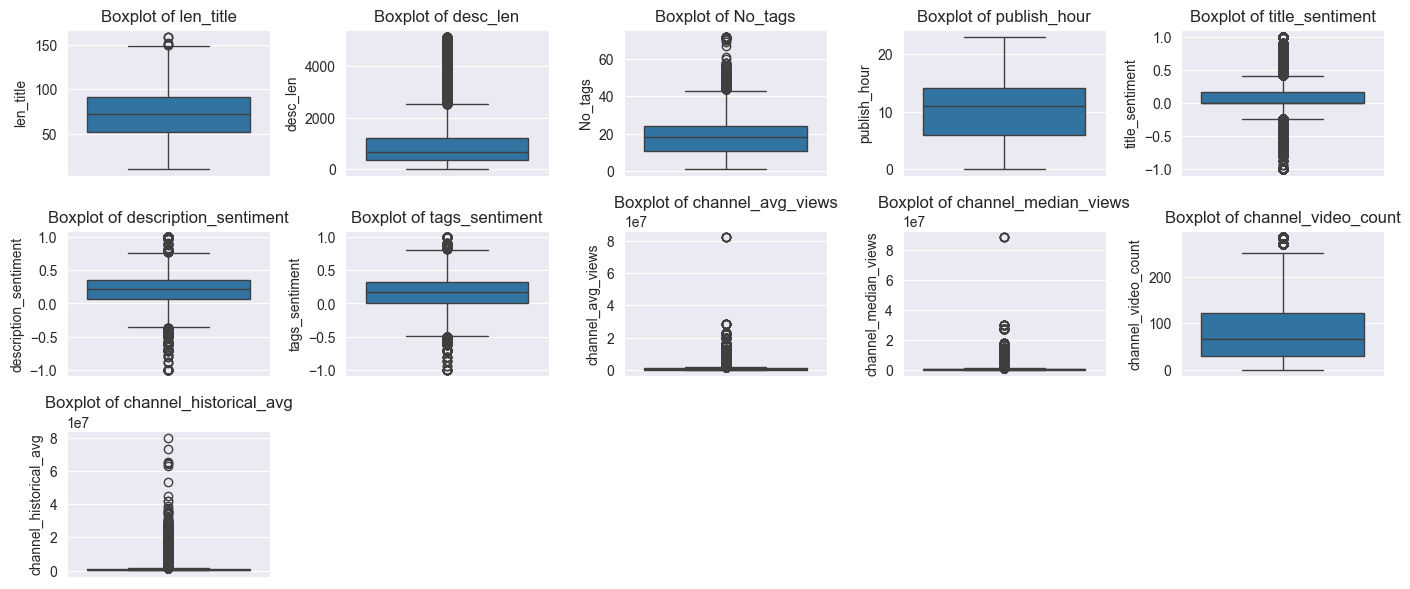

In [8]:
from utils import filter_outliers, plot_dynamic_boxplots_violinplots

# Combine train features and target for outlier detection
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)

# Check outliers on TRAINING data only
excluded_cols = ['is_weekend_publish_day']
check_outliers_cols = [col for col in nums_cols if col not in excluded_cols]
outlier_summary = filter_outliers(df_train, columns=check_outliers_cols, threshold=1.5, detect_only=True)
display(outlier_summary)

# Visualize outliers in training data
plot_dynamic_boxplots_violinplots(df_train, check_outliers_cols, plot_type="boxplot", ncols=5, orientation="v", figsize=(14, 6))

In [9]:
# Remove outliers from TRAINING data and get IQR limits
# These limits will be applied to validation data to ensure consistent distributions
# (This prevents data leakage by using only training statistics)

# Step 1: Get IQR limits from training data
train_outlier_summary = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=True, verbose=False)

# Step 2: Remove outliers from training data
df_train_clean = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=False)
X_train_clean = df_train_clean.drop(columns=[target])
y_train_clean = df_train_clean[target]

# Step 3: Apply SAME IQR limits to validation data (using training-derived thresholds)
# This ensures validation set has the same distribution as training, preventing the mismatch issue
def filter_using_training_limits(data, columns, limits_df):
    """
    Filter outliers using pre-computed IQR limits from training data.
    This prevents data leakage while ensuring consistent distributions.
    """
    mask = pd.Series([True] * len(data), index=data.index)
    
    for _, row in limits_df.iterrows():
        col = row['Column Name']
        if col in columns and col in data.columns:
            lower = row['Lower Limit']
            upper = row['Upper Limit']
            col_mask = (data[col] >= lower) & (data[col] <= upper)
            mask = mask & col_mask
    
    return data[mask]

# Combine validation features and target for filtering
df_val = pd.concat([X_val_raw, y_val_raw], axis=1)
df_val_clean = filter_using_training_limits(df_val, check_outliers_cols, train_outlier_summary)

# Split back into X and y
X_val_clean = df_val_clean.drop(columns=[target])
y_val_clean = df_val_clean[target]

print(f"Training samples after outlier removal: {len(X_train_clean):,}")
print(f"Removed {len(X_train_raw) - len(X_train_clean):,} outlier samples from training set")
print(f"\nValidation samples after applying training limits: {len(X_val_clean):,}")
print(f"Removed {len(X_val_raw) - len(X_val_clean):,} outlier samples from validation set")
print(f"\nTest set: {len(X_test_raw):,} (unchanged - for final evaluation only)")

Training samples after outlier removal: 17,832
Removed 9,761 outlier samples from training set

Validation samples after applying training limits: 4,688
Removed 2,670 outlier samples from validation set

Test set: 1,840 (unchanged - for final evaluation only)


## Feature Encoding

In [10]:
info_df = check_data_information(X_train_raw, X_train_clean.select_dtypes(include='object').columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,category_name,str,0,0.0,0,0.0,0,0.0,0,0,10,16,0.0006,"Comedy, Entertainment, News & Politics, Howto ..."
1,publish_day,str,0,0.0,0,0.0,0,0.0,0,0,10,7,0.0003,"Thursday, Monday, Friday, Sunday, Saturday"
2,publish_month,str,0,0.0,0,0.0,0,0.0,0,0,10,8,0.0003,"March, December, May, February, January"
3,publish_hour_category,str,0,0.0,0,0.0,0,0.0,0,0,10,4,0.0001,"Afternoon, Evening, Night, Morning"
4,title_sentiment_label,str,0,0.0,0,0.0,0,0.0,0,0,10,3,0.0001,"Neutral, Negative, Positive"
5,description_sentiment_label,str,0,0.0,0,0.0,0,0.0,0,0,10,3,0.0001,"Neutral, Positive, Negative"
6,tags_sentiment_label,str,0,0.0,0,0.0,0,0.0,0,0,10,3,0.0001,"Positive, Neutral, Negative"


- Ordinal Encoding: 
    - `title_sentiment_label`
    - `description_sentiment_label`
    - `tags_sentiment_label`

- One-hot Encoding: 
    - `category_name`
    - `publish_day`, `publish_hour_category`, `publish_month`

In [16]:
X_train_clean.info()

<class 'pandas.DataFrame'>
Index: 17832 entries, 20650 to 860
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   category_name                17832 non-null  str    
 1   publish_day                  17832 non-null  str    
 2   publish_month                17832 non-null  str    
 3   publish_hour_category        17832 non-null  str    
 4   title_sentiment_label        17832 non-null  str    
 5   description_sentiment_label  17832 non-null  str    
 6   tags_sentiment_label         17832 non-null  str    
 7   len_title                    17832 non-null  int64  
 8   desc_len                     17832 non-null  int64  
 9   No_tags                      17832 non-null  int64  
 10  is_weekend_publish_day       17832 non-null  int64  
 11  publish_hour                 17832 non-null  int64  
 12  title_sentiment              17832 non-null  float64
 13  description_sentiment        1

In [17]:
from utils import feature_encoding

# Make copies for encoding
X_train_encoded = X_train_clean.copy()
X_val_encoded = X_val_clean.copy()
X_test_encoded = X_test_raw.copy()

# Define categorical columns for feature encoding
ordinal_cols = ['title_sentiment_label', 'description_sentiment_label', 'tags_sentiment_label']
ordinal_categories = {
    "title_sentiment_label": ['Negative', 'Neutral', 'Positive'],
    "description_sentiment_label": ['Negative', 'Neutral', 'Positive'],
    "tags_sentiment_label": ['Negative', 'Neutral', 'Positive']
}

ohe_cols = ['category_name', 'publish_day', 'publish_hour_category', 'publish_month']

# Fit on training data
X_train_encoded, encoders = feature_encoding(
    X_train_encoded,
    ordinal_columns=ordinal_cols,
    ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

# Transform validation data (reuses fitted encoders)
X_val_encoded, _ = feature_encoding(
    X_val_encoded,
    ordinal_columns=ordinal_cols,
    ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

# Transform test data (reuses fitted encoders)
X_test_encoded, _ = feature_encoding(
    X_test_encoded,
    ordinal_columns=ordinal_cols,
    ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

print(f"Encoded features shape: {X_train_encoded.shape}")
print(f"\nFeature columns after encoding:")
print(X_train_encoded.columns.tolist())
print("Re-check the final encoded dataframe:")
display(X_train_encoded.head(3))

Encoded features shape: (17832, 45)

Feature columns after encoding:
['title_sentiment_label', 'description_sentiment_label', 'tags_sentiment_label', 'category_name_Comedy', 'category_name_Education', 'category_name_Entertainment', 'category_name_Film & Animation', 'category_name_Gaming', 'category_name_Howto & Style', 'category_name_Music', 'category_name_News & Politics', 'category_name_Nonprofits & Activism', 'category_name_People & Blogs', 'category_name_Science & Technology', 'category_name_Sports', 'category_name_Travel & Events', 'category_name_Unknown', 'publish_day_Monday', 'publish_day_Saturday', 'publish_day_Sunday', 'publish_day_Thursday', 'publish_day_Tuesday', 'publish_day_Wednesday', 'publish_hour_category_Evening', 'publish_hour_category_Morning', 'publish_hour_category_Night', 'publish_month_December', 'publish_month_February', 'publish_month_January', 'publish_month_June', 'publish_month_March', 'publish_month_May', 'publish_month_November', 'len_title', 'desc_len', '

,title_sentiment_label,description_sentiment_label,tags_sentiment_label,category_name_Comedy,category_name_Education,category_name_Entertainment,category_name_Film & Animation,category_name_Gaming,category_name_Howto & Style,category_name_Music,category_name_News & Politics,category_name_Nonprofits & Activism,category_name_People & Blogs,category_name_Science & Technology,category_name_Sports,category_name_Travel & Events,category_name_Unknown,publish_day_Monday,publish_day_Saturday,publish_day_Sunday,publish_day_Thursday,publish_day_Tuesday,publish_day_Wednesday,publish_hour_category_Evening,publish_hour_category_Morning,publish_hour_category_Night,publish_month_December,publish_month_February,publish_month_January,publish_month_June,publish_month_March,publish_month_May,publish_month_November,len_title,desc_len,No_tags,is_weekend_publish_day,publish_hour,title_sentiment,description_sentiment,tags_sentiment,channel_avg_views,channel_median_views,channel_video_count,channel_historical_avg
20650,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,817,28,0,15,0.000,0.000000,0.338182,695864.587156,614594.0,109,642984.037037
8197,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,60,905,10,0,22,0.000,0.430808,0.175000,519998.191919,470863.0,198,362917.875000
32759,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,101,1575,11,0,12,-0.125,0.451228,0.500000,272888.246914,241890.0,81,232422.870370


## Feature Selection

In [ ]:
# # Heatmap for every date features to target (views)
# plt.figure(figsize=(10, 8))
# mask = np.triu(np.ones_like(feature_engineered_df.corr(numeric_only=True), dtype=bool))
# sns.heatmap(data = feature_engineered_df.corr(numeric_only=True, method='spearman'), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)

In [ ]:
# Re-arrange the columns (views in last)
df_1 = df_encoding.drop(columns='views')
df_2 = df_encoding['views']
df_encoding = pd.concat([df_1, df_2], axis='columns')

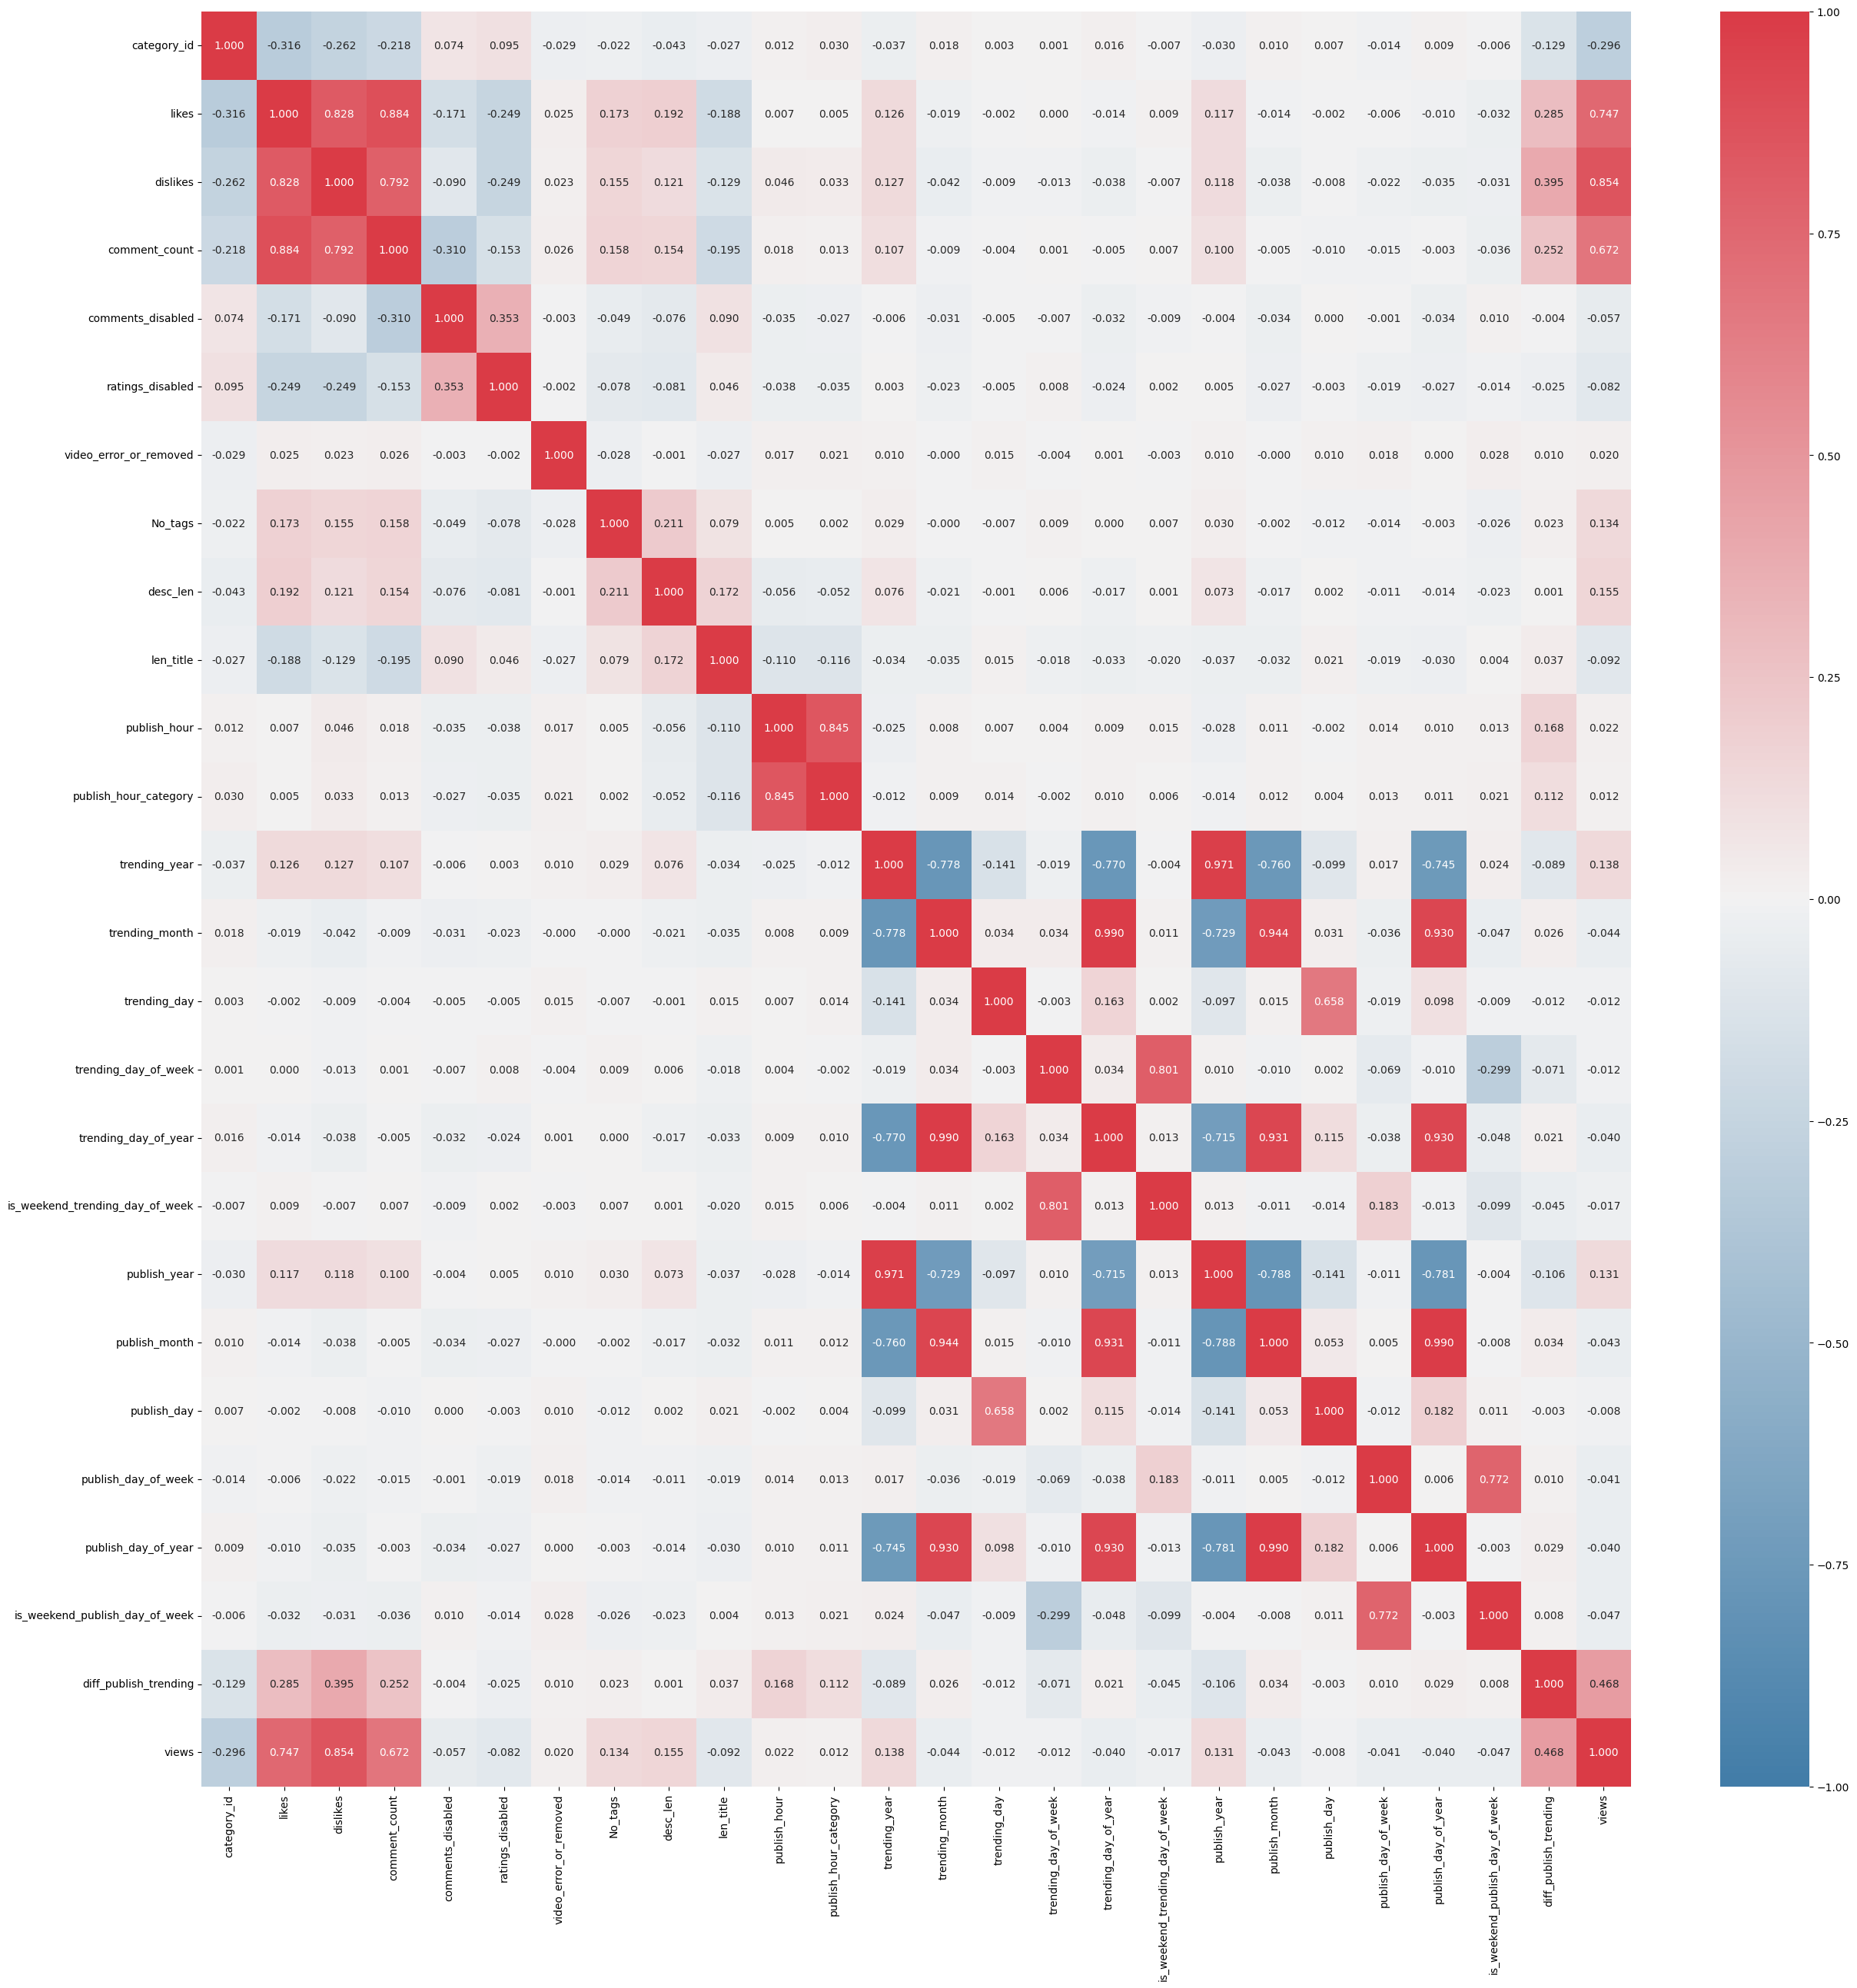

In [ ]:
# Heatmap (corr spearman)
plt.figure(figsize=(30,30))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df_encoding.corr(numeric_only=True, method='spearman'), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In this heatmap correlation analysis, the features to be used include: 'category_id', 'likes', 'dislikes', 'No_tags', 'desc_len', 'diff_days', and features resulting from encoding process based on considerations of the problem context, feature-target correlation, feature-feature correlation. Additionally, redundant features (with high correlation) will be discarded, keeping only one with the highest to target.

In [ ]:
# Create temporary dataframe for testing SelectKBest
df_feature_target_relation = df_encoding.copy()

selected_columns = df_feature_target_relation.columns.difference(['trending_date', 'publish_date', 'publish_time', 'title', 'channel_title', 'tags', 'description'])
df_feature_target_relation = df_feature_target_relation[selected_columns]

# df_feature_target_relation = df_feature_target_relation.loc[:, ~df_feature_target_relation.columns.isin(['trending_date', 'publish_date', 'publish_time', 'title', 'channel_title', 'tags', 'description'])]
# df_feature_target_relation.head()

In [ ]:
#Calculation of feature importance score to target (numerical/categorical feature - numerical target)

from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Separate features and target variable
x_features_test = df_feature_target_relation.drop(columns=['views'])  # Features
y_target_test = df_feature_target_relation['views']  # Target variable

# Instantiate SelectKBest
k_best = SelectKBest(score_func=mutual_info_regression, k='all')  # Use 'all' to see scores for all features

# Fit and transform the data
x_selected_features = k_best.fit_transform(x_features_test, y_target_test)

# Get scores, p-values, and feature names
feature_scores = k_best.scores_
p_values = k_best.pvalues_
feature_names = x_features_test.columns

# Create a DataFrame to display feature scores and p-values
feature_scores_df = pd.DataFrame({'Feature': feature_names, 'Score': feature_scores, 'P-value': p_values})
feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

# Display the feature scores and p-values
print(feature_scores_df)

                            Feature     Score P-value
6                          dislikes  0.751994    None
10                            likes  0.572688    None
2                     comment_count  0.425837    None
5             diff_publish_trending  0.166835    None
4                          desc_len  0.118112    None
1                       category_id  0.118016    None
0                           No_tags  0.060124    None
9                         len_title  0.047520    None
13              publish_day_of_year  0.037192    None
21             trending_day_of_year  0.036821    None
14                     publish_hour  0.032550    None
16                    publish_month  0.026560    None
22                   trending_month  0.026198    None
19                     trending_day  0.019592    None
12              publish_day_of_week  0.014492    None
11                      publish_day  0.011524    None
20             trending_day_of_week  0.009303    None
15            publish_hour_c

In [ ]:
#Calculation of feature importance score to target (numerical/categorical feature - numerical target)

from sklearn.feature_selection import SelectKBest, chi2

# Separate features and target variable
x_features_test = df_feature_target_relation.drop(columns=['views'])  # Features
y_target_test = df_feature_target_relation['views']  # Target variable

# Instantiate SelectKBest
k_best = SelectKBest(score_func=chi2, k='all')  # Use 'all' to see scores for all features

# Fit and transform the data
x_selected_features = k_best.fit_transform(x_features_test, y_target_test)

# Get scores, p-values, and feature names
feature_scores = k_best.scores_
p_values = k_best.pvalues_
feature_names = x_features_test.columns

# Create a DataFrame to display feature scores and p-values
feature_scores_df = pd.DataFrame({'Feature': feature_names, 'Score': feature_scores, 'P-value': p_values})
feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

# Display the feature scores and p-values
print(feature_scores_df)

                            Feature         Score        P-value
10                            likes  1.185153e+10   0.000000e+00
6                          dislikes  5.914666e+09   0.000000e+00
2                     comment_count  2.815873e+09   0.000000e+00
4                          desc_len  2.286258e+07   0.000000e+00
13              publish_day_of_year  3.318660e+06   0.000000e+00
21             trending_day_of_year  3.308621e+06   0.000000e+00
9                         len_title  2.238157e+05   0.000000e+00
0                           No_tags  1.647303e+05   0.000000e+00
19                     trending_day  1.531669e+05   0.000000e+00
11                      publish_day  1.528876e+05   0.000000e+00
16                    publish_month  9.728568e+04   0.000000e+00
22                   trending_month  9.710486e+04   0.000000e+00
14                     publish_hour  8.230285e+04   0.000000e+00
5             diff_publish_trending  7.219906e+04   0.000000e+00
1                       c

**Reminder About P-Values**

In statistical hypothesis testing, the p-value is a measure that helps you assess the evidence against a null hypothesis. In the context of evaluating selected features for model training, p-values are often associated with statistical tests, such as t-tests or ANOVA, to determine whether there is a significant difference between groups.

Here's a general guideline:

1. **Null Hypothesis (\(H_0\)):** The null hypothesis typically assumes that there is no significant relationship or difference between groups.
   
2. **Alternative Hypothesis (\(H_1\) or \(H_a\)):** The alternative hypothesis suggests that there is a significant relationship or difference.

3. **P-value Interpretation:**
   - If the p-value is less than or equal to your chosen significance level (often 0.05), you reject the null hypothesis. This suggests that there is enough evidence to conclude that there is a significant relationship or difference.
   - If the p-value is greater than your chosen significance level, you fail to reject the null hypothesis. This implies that there is not enough evidence to conclude a significant relationship or difference.

However, it's crucial to note a few considerations:

- **Multiple Comparisons:** When you're evaluating multiple features simultaneously, there is a risk of inflated Type I error (false positives) due to multiple comparisons. In such cases, you might want to apply a correction method (like Bonferroni correction) to adjust the significance level.

- **Effect Size:** Even if a result is statistically significant, it might not be practically significant. Therefore, it's important to consider the effect size along with p-values.

- **Domain Knowledge:** Statistical significance does not guarantee practical importance. Consider the context and domain-specific knowledge when interpreting results.

- **Model Performance:** P-values alone might not be sufficient for feature selection. It's crucial to also consider how well the selected features contribute to the overall performance of your predictive model.

In summary, while a commonly used threshold is a p-value less than 0.05, the interpretation should be made in the context of your study, and it's essential to consider additional factors like effect size, domain knowledge, and overall model performance.

In [ ]:
#Checking the columns
df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32562 entries, 0 to 36769
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   trending_date                    32562 non-null  datetime64[ns]
 1   title                            32562 non-null  object        
 2   channel_title                    32562 non-null  object        
 3   category_id                      32562 non-null  int64         
 4   publish_time                     32562 non-null  object        
 5   tags                             32562 non-null  object        
 6   likes                            32562 non-null  int64         
 7   dislikes                         32562 non-null  int64         
 8   comment_count                    32562 non-null  int64         
 9   comments_disabled                32562 non-null  int32         
 10  ratings_disabled                 32562 non-null  int32         

In [ ]:
# Select only relevant features

df_model = df_encoding.copy()

#Using all features
selected_features = df_encoding.select_dtypes(['float64', 'int8', 'int32', 'int64', 'boolean']).columns

# #Using label or freq encoding
# selected_features = ['category_id', 'dislikes', 'No_tags', 'desc_len',
#                      'diff_publish_trending', 'views']

# #Using OHE
# selected_features = ['category_id', 'likes', 'dislikes', 'No_tags', 'desc_len', 'diff_publish_trending',
#                      'comments_disabled_False','comments_disabled_True', 'ratings_disabled_False',
#                      'ratings_disabled_True', 'video_error_or_removed_False', 'video_error_or_removed_True', 'views']

df_model = df_model[selected_features]
df_model.sample(5)

,category_id,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,No_tags,desc_len,len_title,publish_hour,publish_hour_category,trending_year,trending_month,trending_day,trending_day_of_week,trending_day_of_year,is_weekend_trending_day_of_week,publish_year,publish_month,publish_day,publish_day_of_week,publish_day_of_year,is_weekend_publish_day_of_week,diff_publish_trending,views
9854,22,781,135,49,0,0,0,6,615,97,12,0,2018,1,6,5,6,1,2018,1,4,3,4,0,2.0,94094
29483,1,3290,342,168,0,0,0,20,352,22,14,1,2018,5,5,5,125,1,2018,5,3,3,123,0,2.0,167862
6960,24,7187,425,878,0,0,0,8,198,87,14,1,2017,12,21,3,355,0,2017,12,19,1,353,0,2.0,230503
20547,23,33138,2344,1674,0,0,0,27,273,31,13,1,2018,3,10,5,69,1,2018,3,6,1,65,0,4.0,697011
3995,27,764,40,77,0,0,0,33,859,98,7,0,2017,12,5,1,339,0,2017,12,4,0,338,0,1.0,28111


## Train-Test Split

In [ ]:
# Spliting data into train-test
x = df_model.drop(columns=['views'])
y = df_model[['views']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

## Handling Outliers

It is generally recommended to handle outliers based on the training data only. The reason for this is to simulate real-world conditions during the testing phase. Handling outliers in the test set could potentially distort the evaluation of the model's performance on unseen data.

Here's the typical process:

1. **Handling outliers in the training data:** Identify and handle outliers using methods like IQR (Interquartile Range) or Z-score on the training dataset. This helps the model learn from a cleaner dataset and improves its generalization.

2. **Applying the same transformation to the test data:** Use the same parameters (like median and standard deviation for Z-score) obtained from the training data to handle outliers in the test data. This ensures consistency and reflects the real-world scenario where the model encounters new, unseen data with potential outliers.

By following this approach, you are testing the model on data that resembles what it might encounter in the real world, including outliers. This provides a more accurate assessment of how well the model generalizes to new, unseen data.

In [ ]:
#Make temporary dataframe of features and target for train set
df_train_handling_outliers = pd.concat([x_train, y_train], axis='columns')

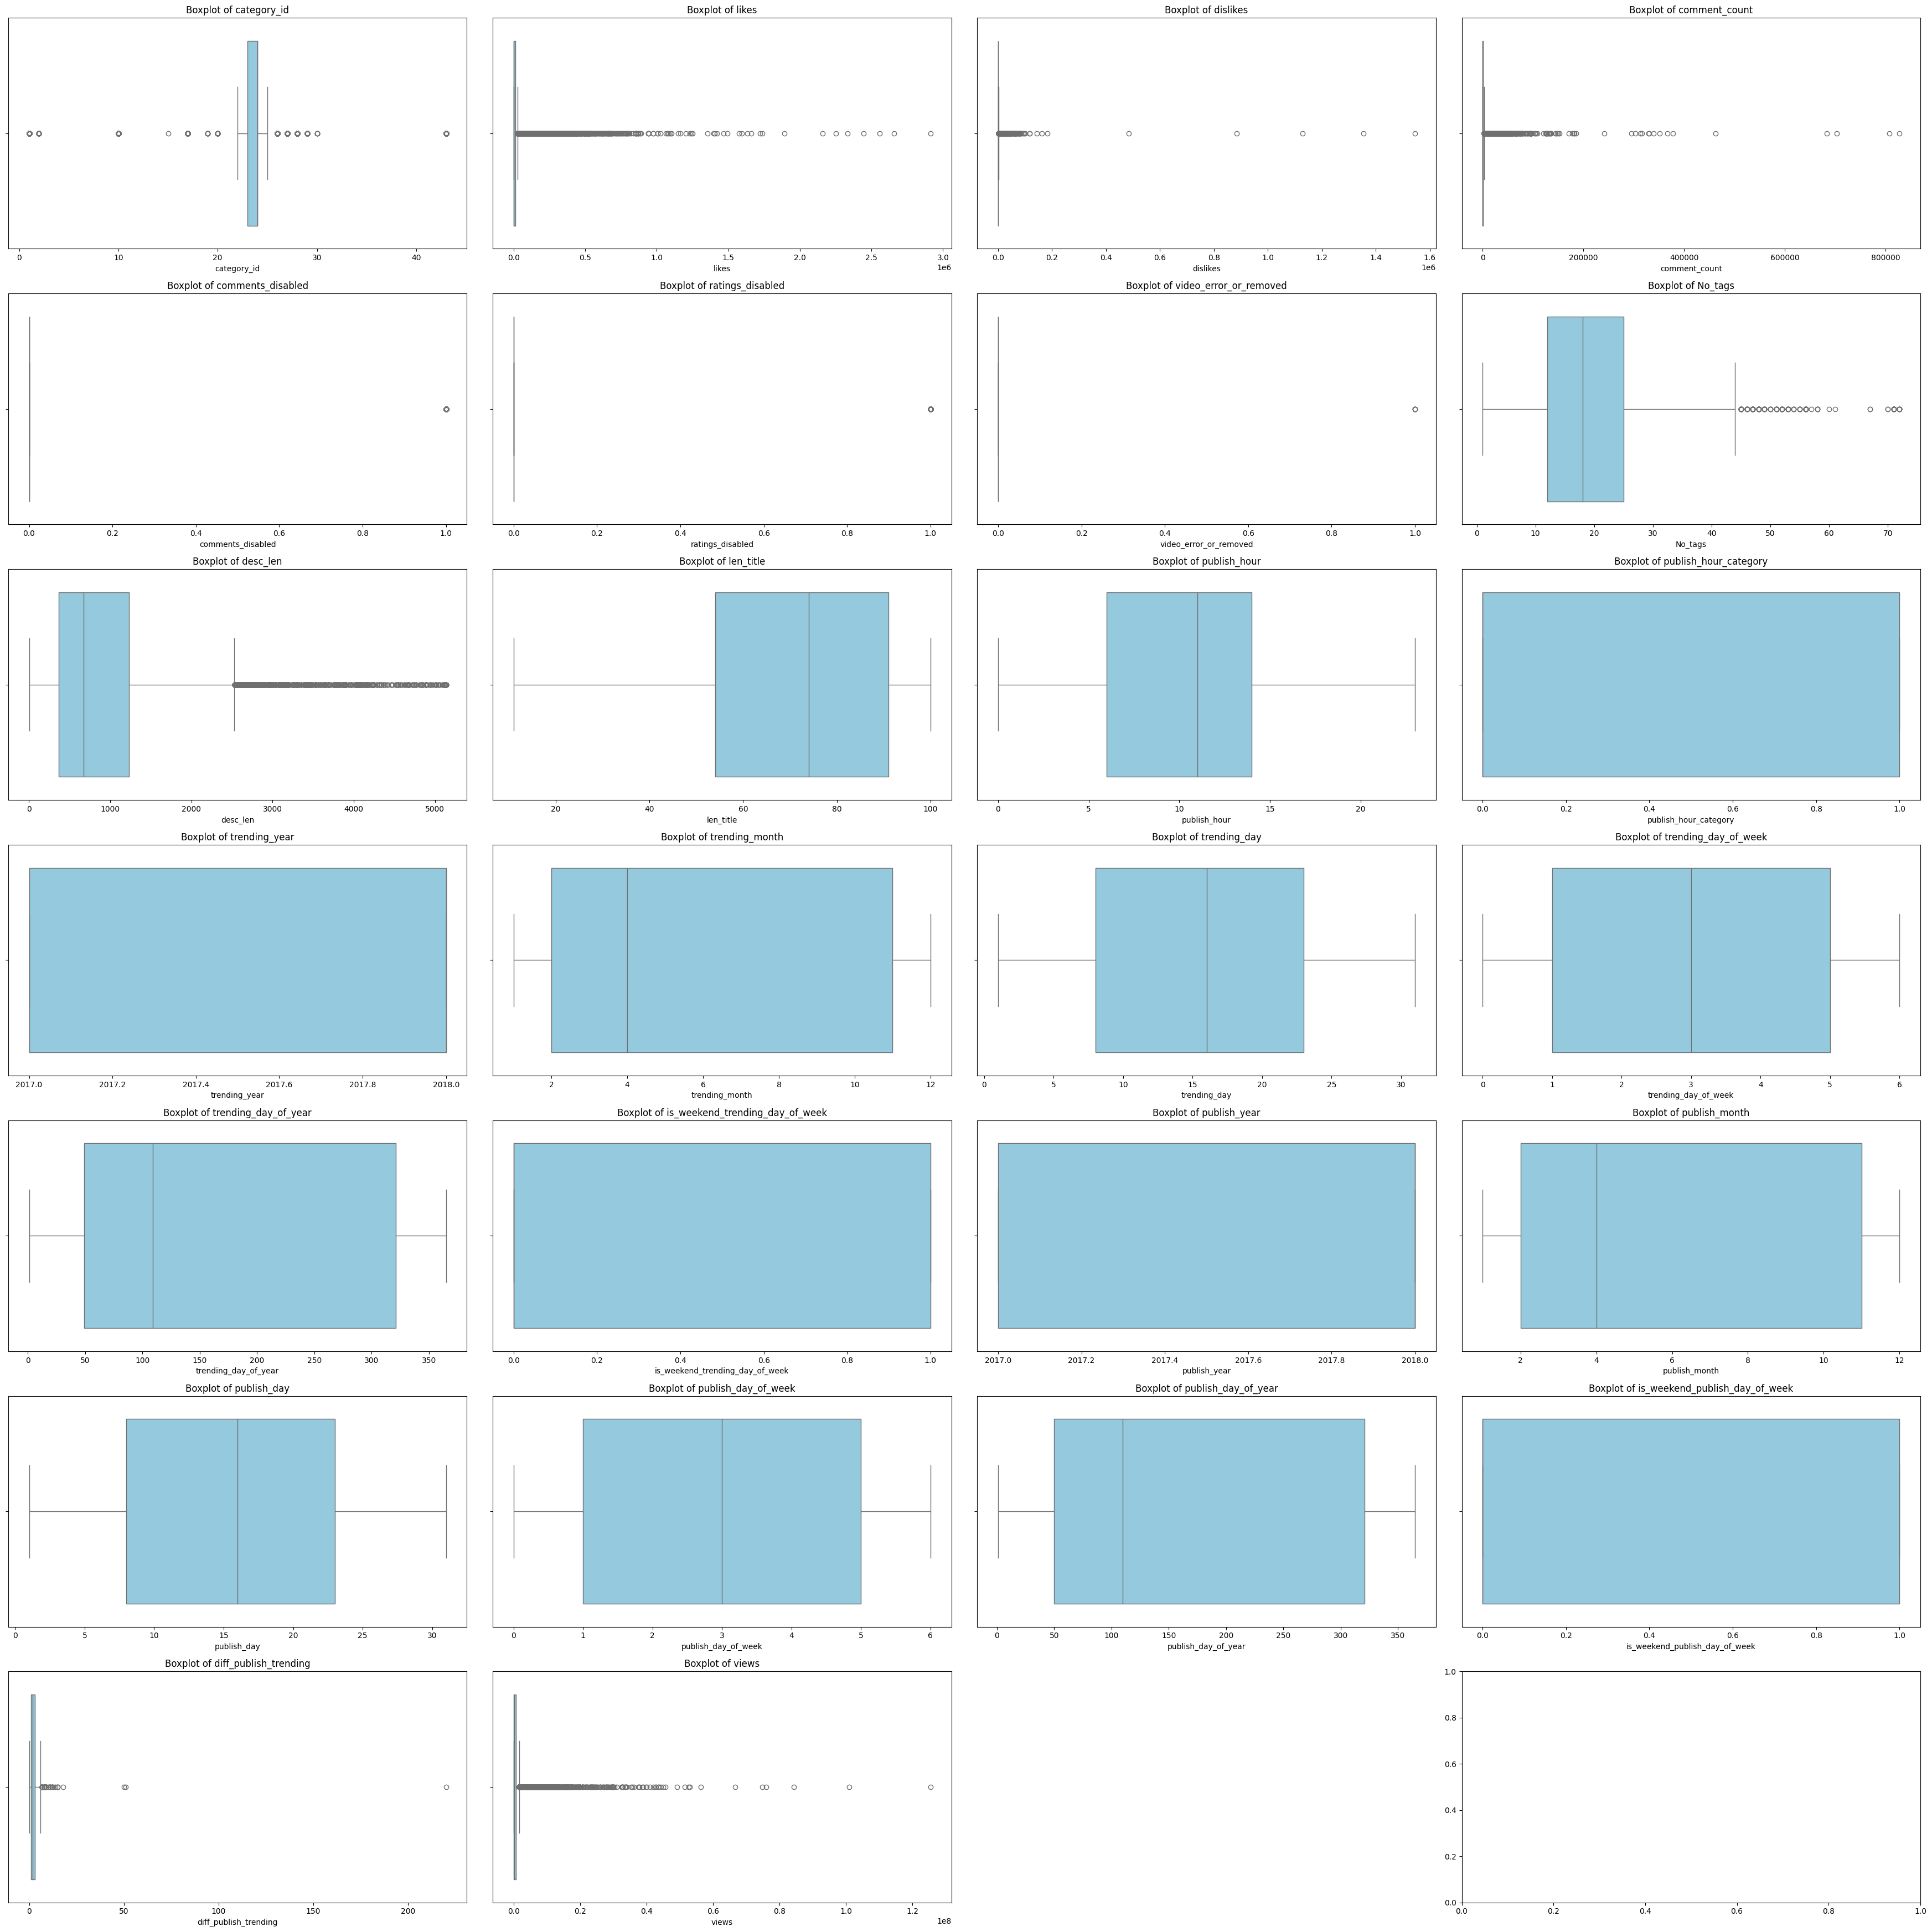

In [ ]:
# Boxplot to check outliers
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(35, 35))
axes = axes.flatten()

for i in range(len(df_train_handling_outliers.columns)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=df_train_handling_outliers.columns[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {df_train_handling_outliers.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(df_train_handling_outliers.columns) < len(axes) :
    axes[len(df_train_handling_outliers.columns)].remove()

plt.tight_layout()

In [ ]:
columns_to_handle_outliers = ['category_id', 'likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'diff_publish_trending']

In [ ]:
# Remove outliers with IQR method

print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

filtered_entries = np.array([True] * len(df_train_handling_outliers))

# Select features with outliers
for col in columns_to_handle_outliers:

    Q1 = df_train_handling_outliers[col].quantile(0.25)
    Q3 = df_train_handling_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)

    filtered_entries = ((df_train_handling_outliers[col] >= lower_bound) & (df_train_handling_outliers[col] <= upper_bound)) & filtered_entries

df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

The number of rows before filtering out outliers : 22793
The number of rows after filtering out outliers: 13937


In [ ]:
# # Remove outliers with z-score method

# from scipy import stats

# print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

# filtered_entries = np.array([True] * len(df_train_handling_outliers))

# # Select features with outliers
# for col in columns_to_handle_outliers:
#     zscore = abs(stats.zscore(df_train_handling_outliers[col])) # calculate the absolute z-score
#     filtered_entries = (zscore < 3) & filtered_entries # keep z-score values less than absolute 3

# df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

# print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

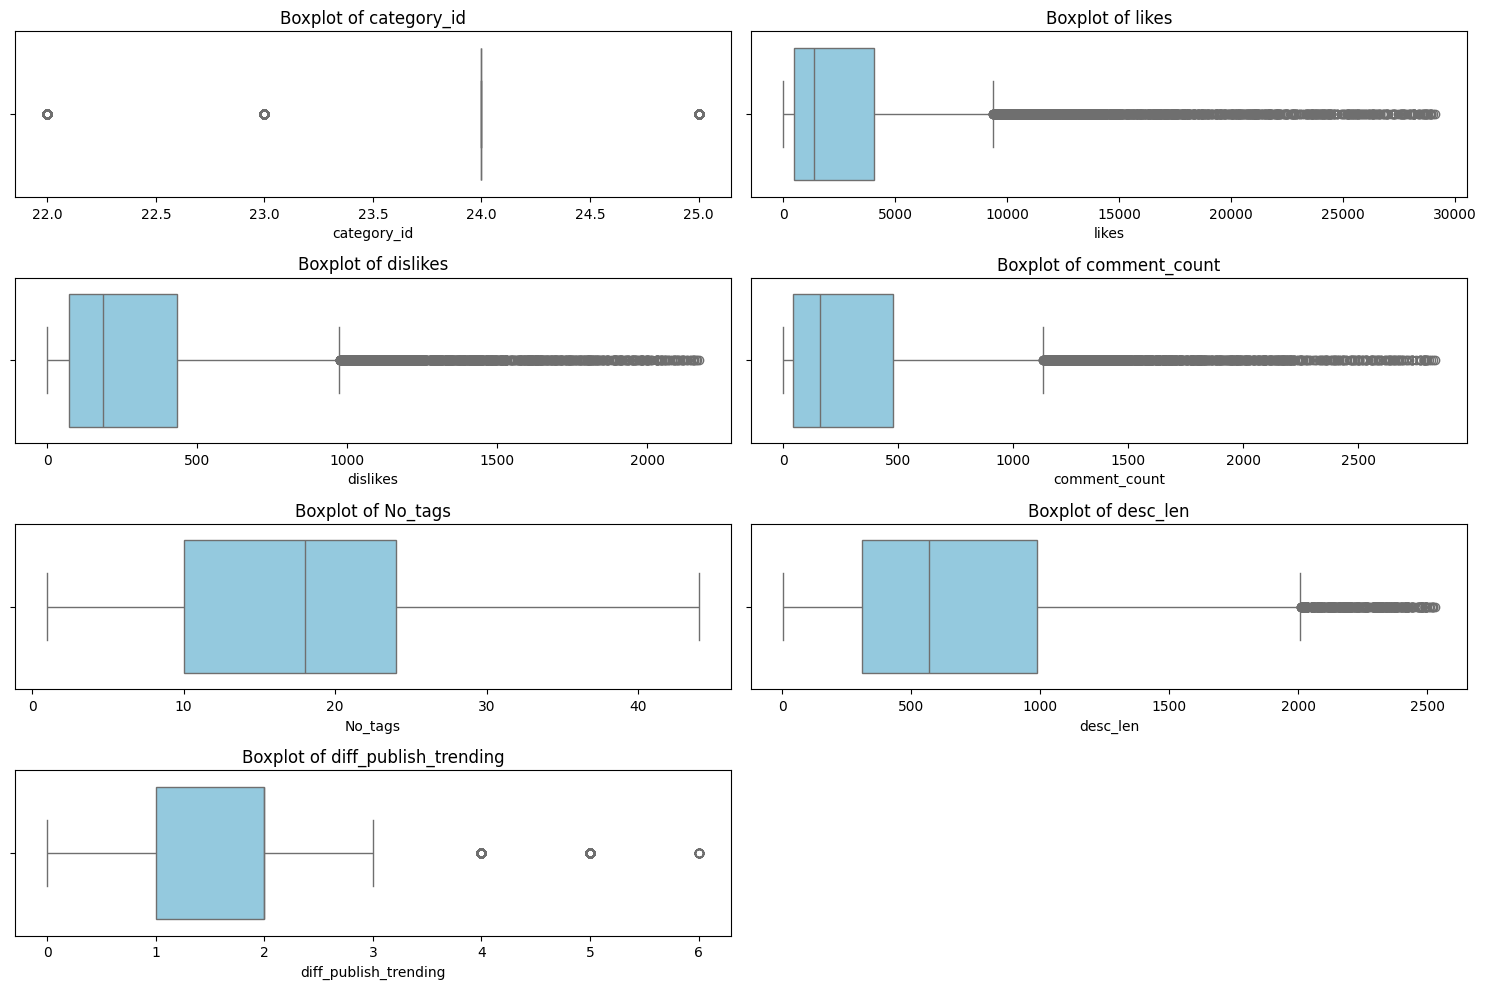

In [ ]:
# Boxplot after handling outliers
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i in range(len(columns_to_handle_outliers)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=columns_to_handle_outliers[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {columns_to_handle_outliers[i]}')


# Remove the last subplot if there are fewer features than subplots
if len(columns_to_handle_outliers) < len(axes):
    axes[len(columns_to_handle_outliers)].remove()

plt.tight_layout()

In [ ]:
#Split the features and target for train set again
x_train = df_train_handling_outliers.drop(columns='views')
y_train = df_train_handling_outliers['views']

## Feature Scaling

Scaling will be done to train and test data

In [ ]:
x_train

,category_id,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,No_tags,desc_len,len_title,publish_hour,publish_hour_category,trending_year,trending_month,trending_day,trending_day_of_week,trending_day_of_year,is_weekend_trending_day_of_week,publish_year,publish_month,publish_day,publish_day_of_week,publish_day_of_year,is_weekend_publish_day_of_week,diff_publish_trending
20257,24,422,55,23,0,0,0,27,465,54,4,0,2018,3,8,3,67,0,2018,3,7,2,66,0,1.0
1216,24,1186,129,360,0,0,0,12,373,72,8,0,2017,11,20,0,324,0,2017,11,19,6,323,1,1.0
36295,24,5264,1053,525,0,0,0,7,2232,43,2,0,2018,6,12,1,163,0,2018,6,10,6,161,1,2.0
10227,23,12736,349,1537,0,0,0,31,363,49,12,0,2018,1,8,0,8,0,2018,1,6,5,6,1,2.0
12728,23,9842,574,488,0,0,0,1,181,57,6,0,2018,1,23,1,23,0,2018,1,20,5,20,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6312,24,3781,148,267,0,0,0,13,86,65,14,1,2017,12,17,6,351,1,2017,12,16,5,350,1,1.0
22272,22,3348,357,214,0,0,0,12,84,84,6,0,2018,3,20,1,79,0,2018,3,19,0,78,0,1.0
5437,24,50,21,8,0,0,0,35,211,98,12,0,2017,12,13,2,347,0,2017,12,12,1,346,0,1.0
860,24,135,160,17,0,0,0,21,1149,98,13,1,2017,11,18,5,322,1,2017,11,15,2,319,0,3.0


In [ ]:
x_test

,category_id,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,No_tags,desc_len,len_title,publish_hour,publish_hour_category,trending_year,trending_month,trending_day,trending_day_of_week,trending_day_of_year,is_weekend_trending_day_of_week,publish_year,publish_month,publish_day,publish_day_of_week,publish_day_of_year,is_weekend_publish_day_of_week,diff_publish_trending
14253,25,1863,472,444,0,0,0,21,751,48,5,0,2018,2,1,3,32,0,2018,1,29,0,29,0,3.0
23082,27,3058,662,280,0,0,0,29,612,100,7,0,2018,3,25,6,84,1,2018,3,24,5,83,1,1.0
31715,23,1209,83,62,0,0,0,33,217,65,17,1,2018,5,17,3,137,0,2018,5,16,2,136,0,1.0
5714,27,2570,86,170,0,0,0,26,788,96,18,1,2017,12,14,3,348,0,2017,12,12,1,346,0,2.0
7874,24,3634,349,550,0,0,0,8,198,86,9,0,2017,12,26,1,360,0,2017,12,24,6,358,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36659,24,21543,2579,1250,0,0,0,33,1564,27,15,1,2018,6,14,3,165,0,2018,6,12,1,163,0,2.0
21663,27,5096,437,1339,0,0,0,29,300,41,14,1,2018,3,17,5,76,1,2018,3,15,3,74,0,2.0
32521,25,1118,443,259,0,0,0,11,357,59,20,1,2018,5,22,1,142,0,2018,5,20,6,140,1,2.0
27131,24,2329,236,201,0,0,0,2,421,67,6,0,2018,4,22,6,112,1,2018,4,20,4,110,0,2.0


**Additional Reminder About Feature Scalling**

When the original distribution is right-skewed, meaning that the majority of the data is concentrated on the left side with a long tail to the right, it's often more appropriate to use transformations that are less sensitive to extreme values. In this case, Min-Max scaling may be a better choice than Z-score normalization.

Here's a brief explanation:

1. **Min-Max Scaling:**
   - Scales the data to a specific range (e.g., between 0 and 1).
   - Less affected by outliers compared to Z-score normalization.
   - Suitable when the distribution is not normal and skewed.

2. **Z-score Normalization (Standardization):**
   - Centers the data around the mean and scales it by the standard deviation.
   - Can be sensitive to outliers, and right-skewed distributions may have extreme values that influence the scaling.
   - More appropriate when the data is approximately normally distributed.

Given a right-skewed distribution, Min-Max scaling is often a better choice as it allows the preservation of the skewed shape of the distribution and avoids amplifying the impact of outliers. However, the choice may also depend on the specific characteristics of your data and the requirements of your modeling task. If your data has extreme outliers, you might also consider other robust scaling methods.

In [ ]:
len(x_train.columns)

25

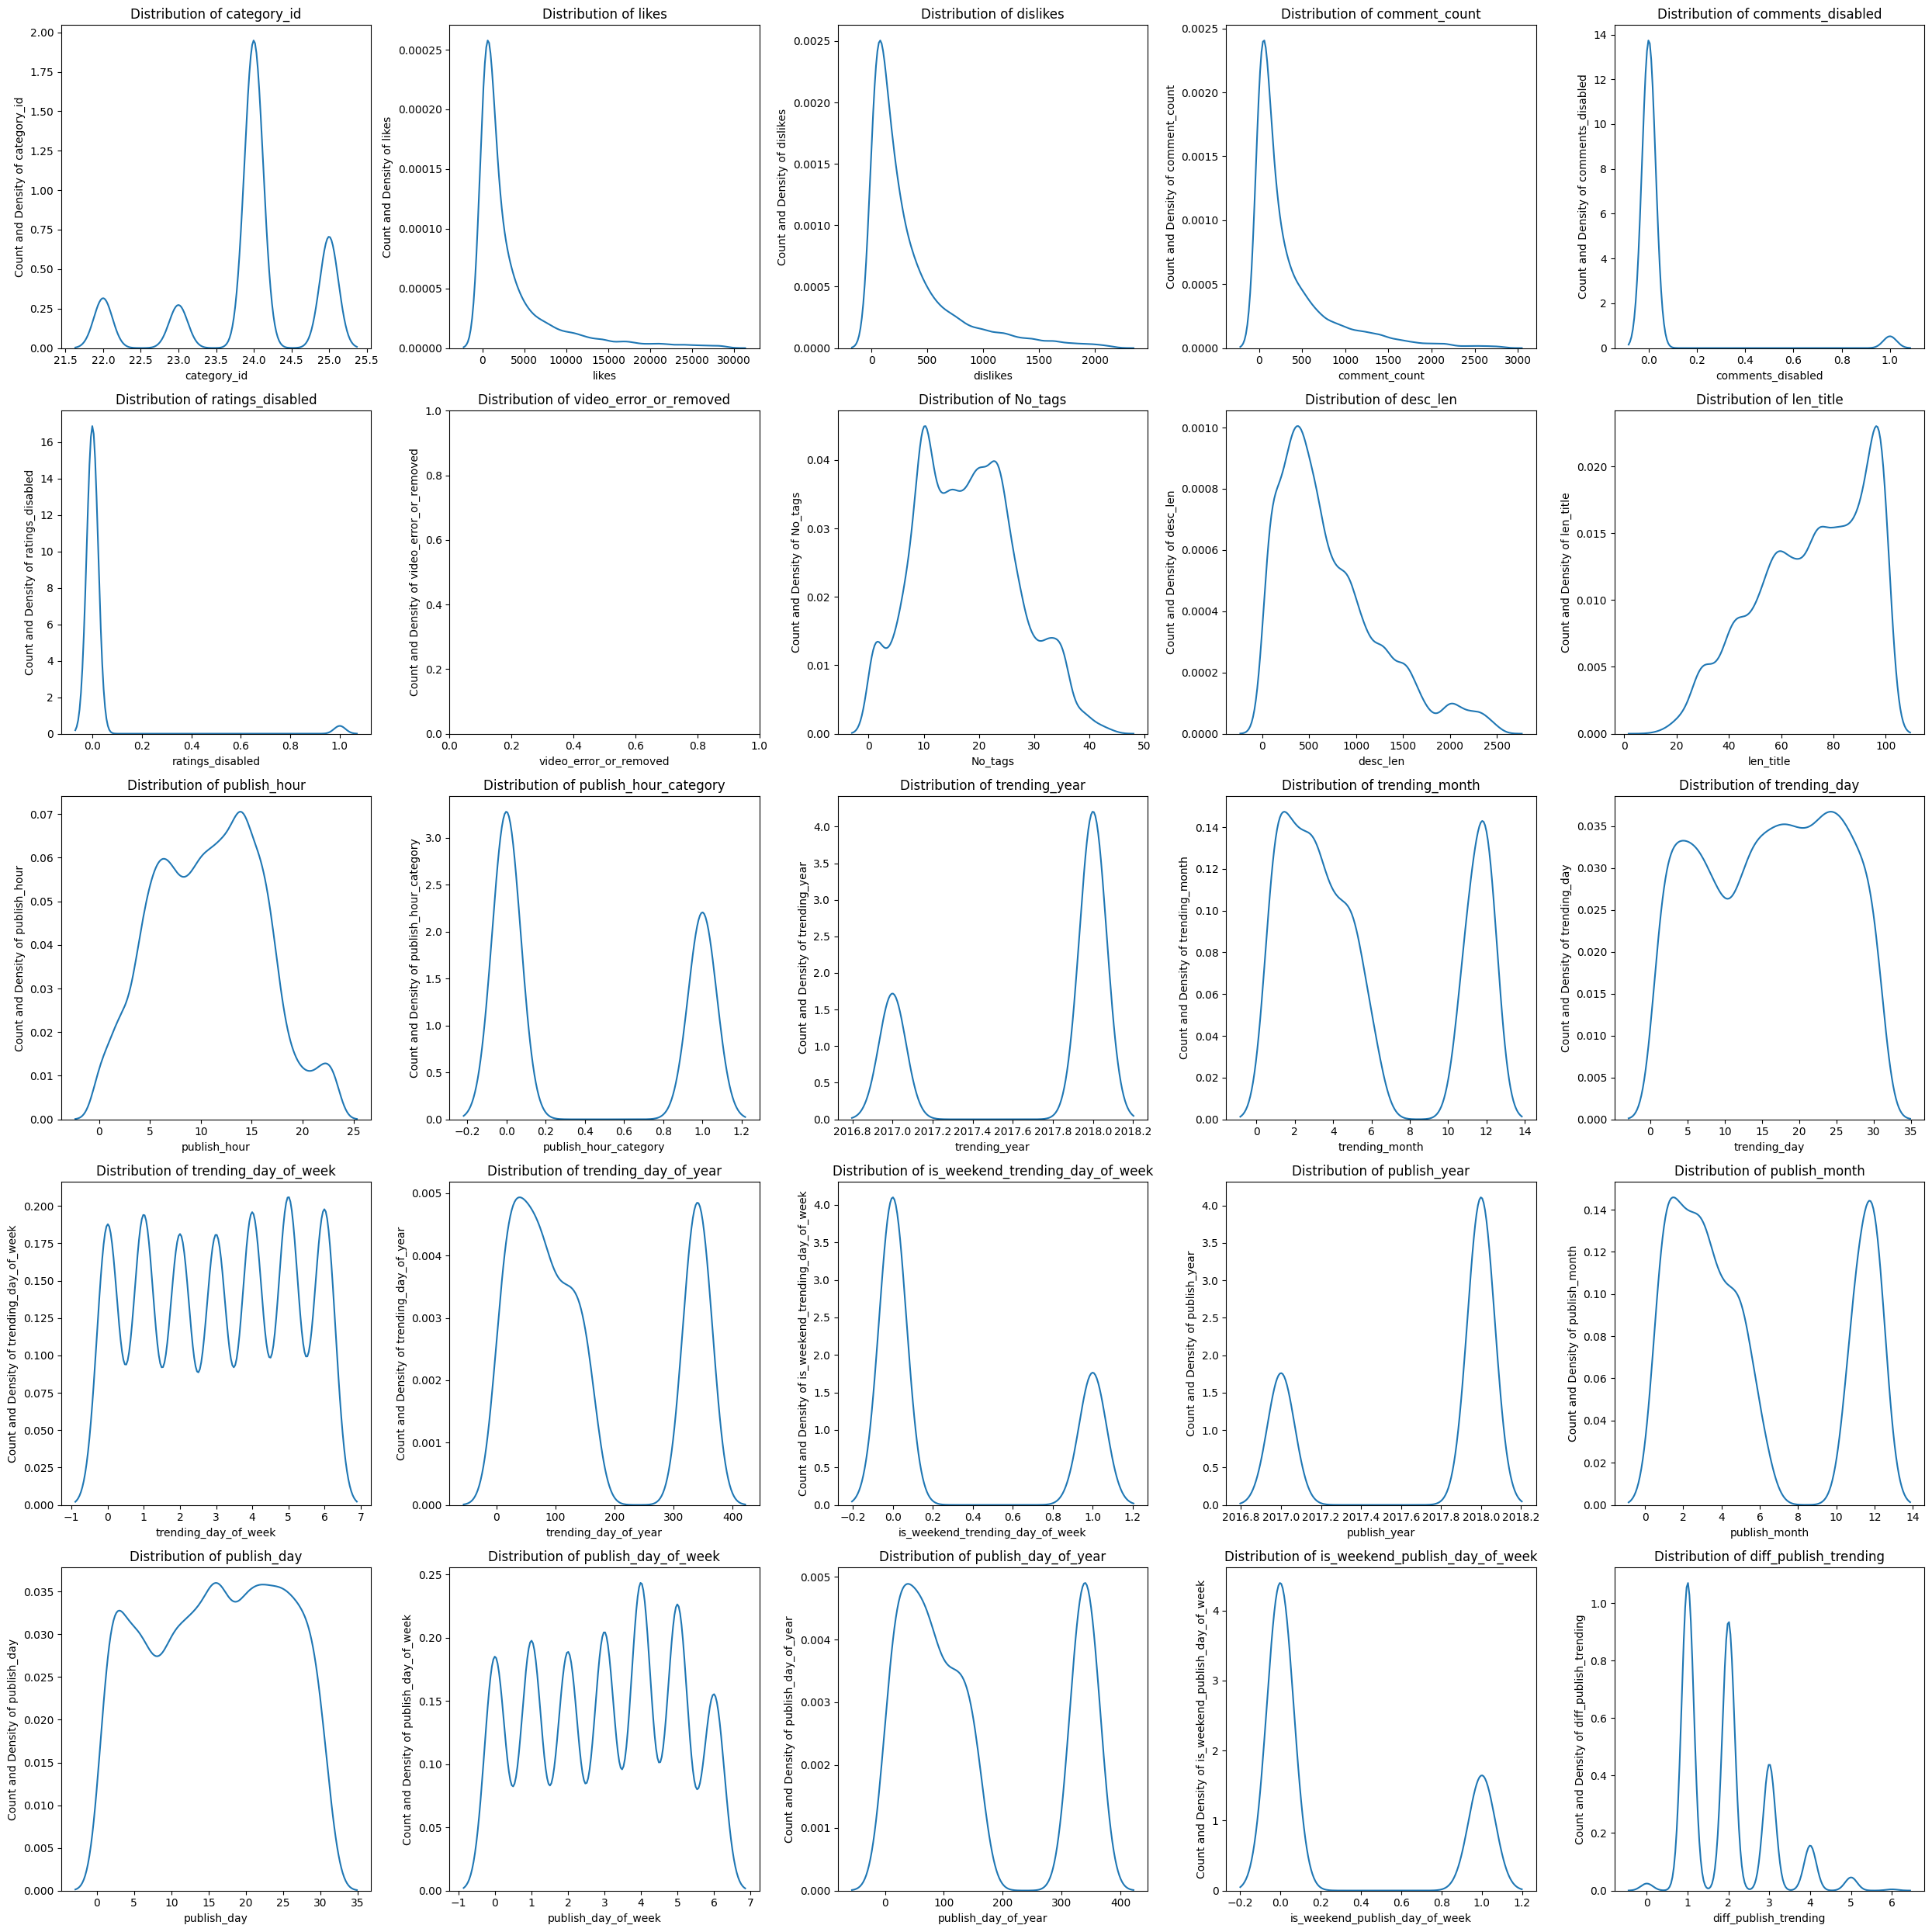

In [ ]:
# Checking distribution before scaling
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25,25))
axes = axes.flatten()

for i in range(len(x_train.columns)) :
    sns.kdeplot(data=x_train, ax=axes[i], x=x_train.columns[i])
    axes[i].set_title(f'Distribution of {x_train.columns[i]}')
    axes[i].set_ylabel(f'Count and Density of {x_train.columns[i]}')
    axes[i].set_xlabel(f'{x_train.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(x_train.columns) < len(axes) :
    axes[len(x_train.columns)].remove()

plt.tight_layout()

Scaling will not be done to all features, but only to features with have large numbers such as likes, dislikes, and desc_len, also the frequency encoded binary columns if we use them

In [ ]:
#Normalization (MinMaxScaller)
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

columns_to_scale = x_train.columns

x_train[columns_to_scale] = ms.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = ms.transform(x_test[columns_to_scale])

In [ ]:
#Robust Scaling
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

columns_to_scale = ['category_id', 'likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'diff_publish_trending']

x_train[columns_to_scale] = rs.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale] = rs.transform(x_test[columns_to_scale])

In [ ]:
# #Standardization (Z-score normalization)
# from sklearn.preprocessing import StandardScaler

# ss = StandardScaler()

# columns_to_scale = ['likes', 'dislikes', 'No_tags', 'desc_len']

# x_train[columns_to_scale] = ss.fit_transform(x_train[columns_to_scale])
# x_test[columns_to_scale] = ss.transform(x_test[columns_to_scale])

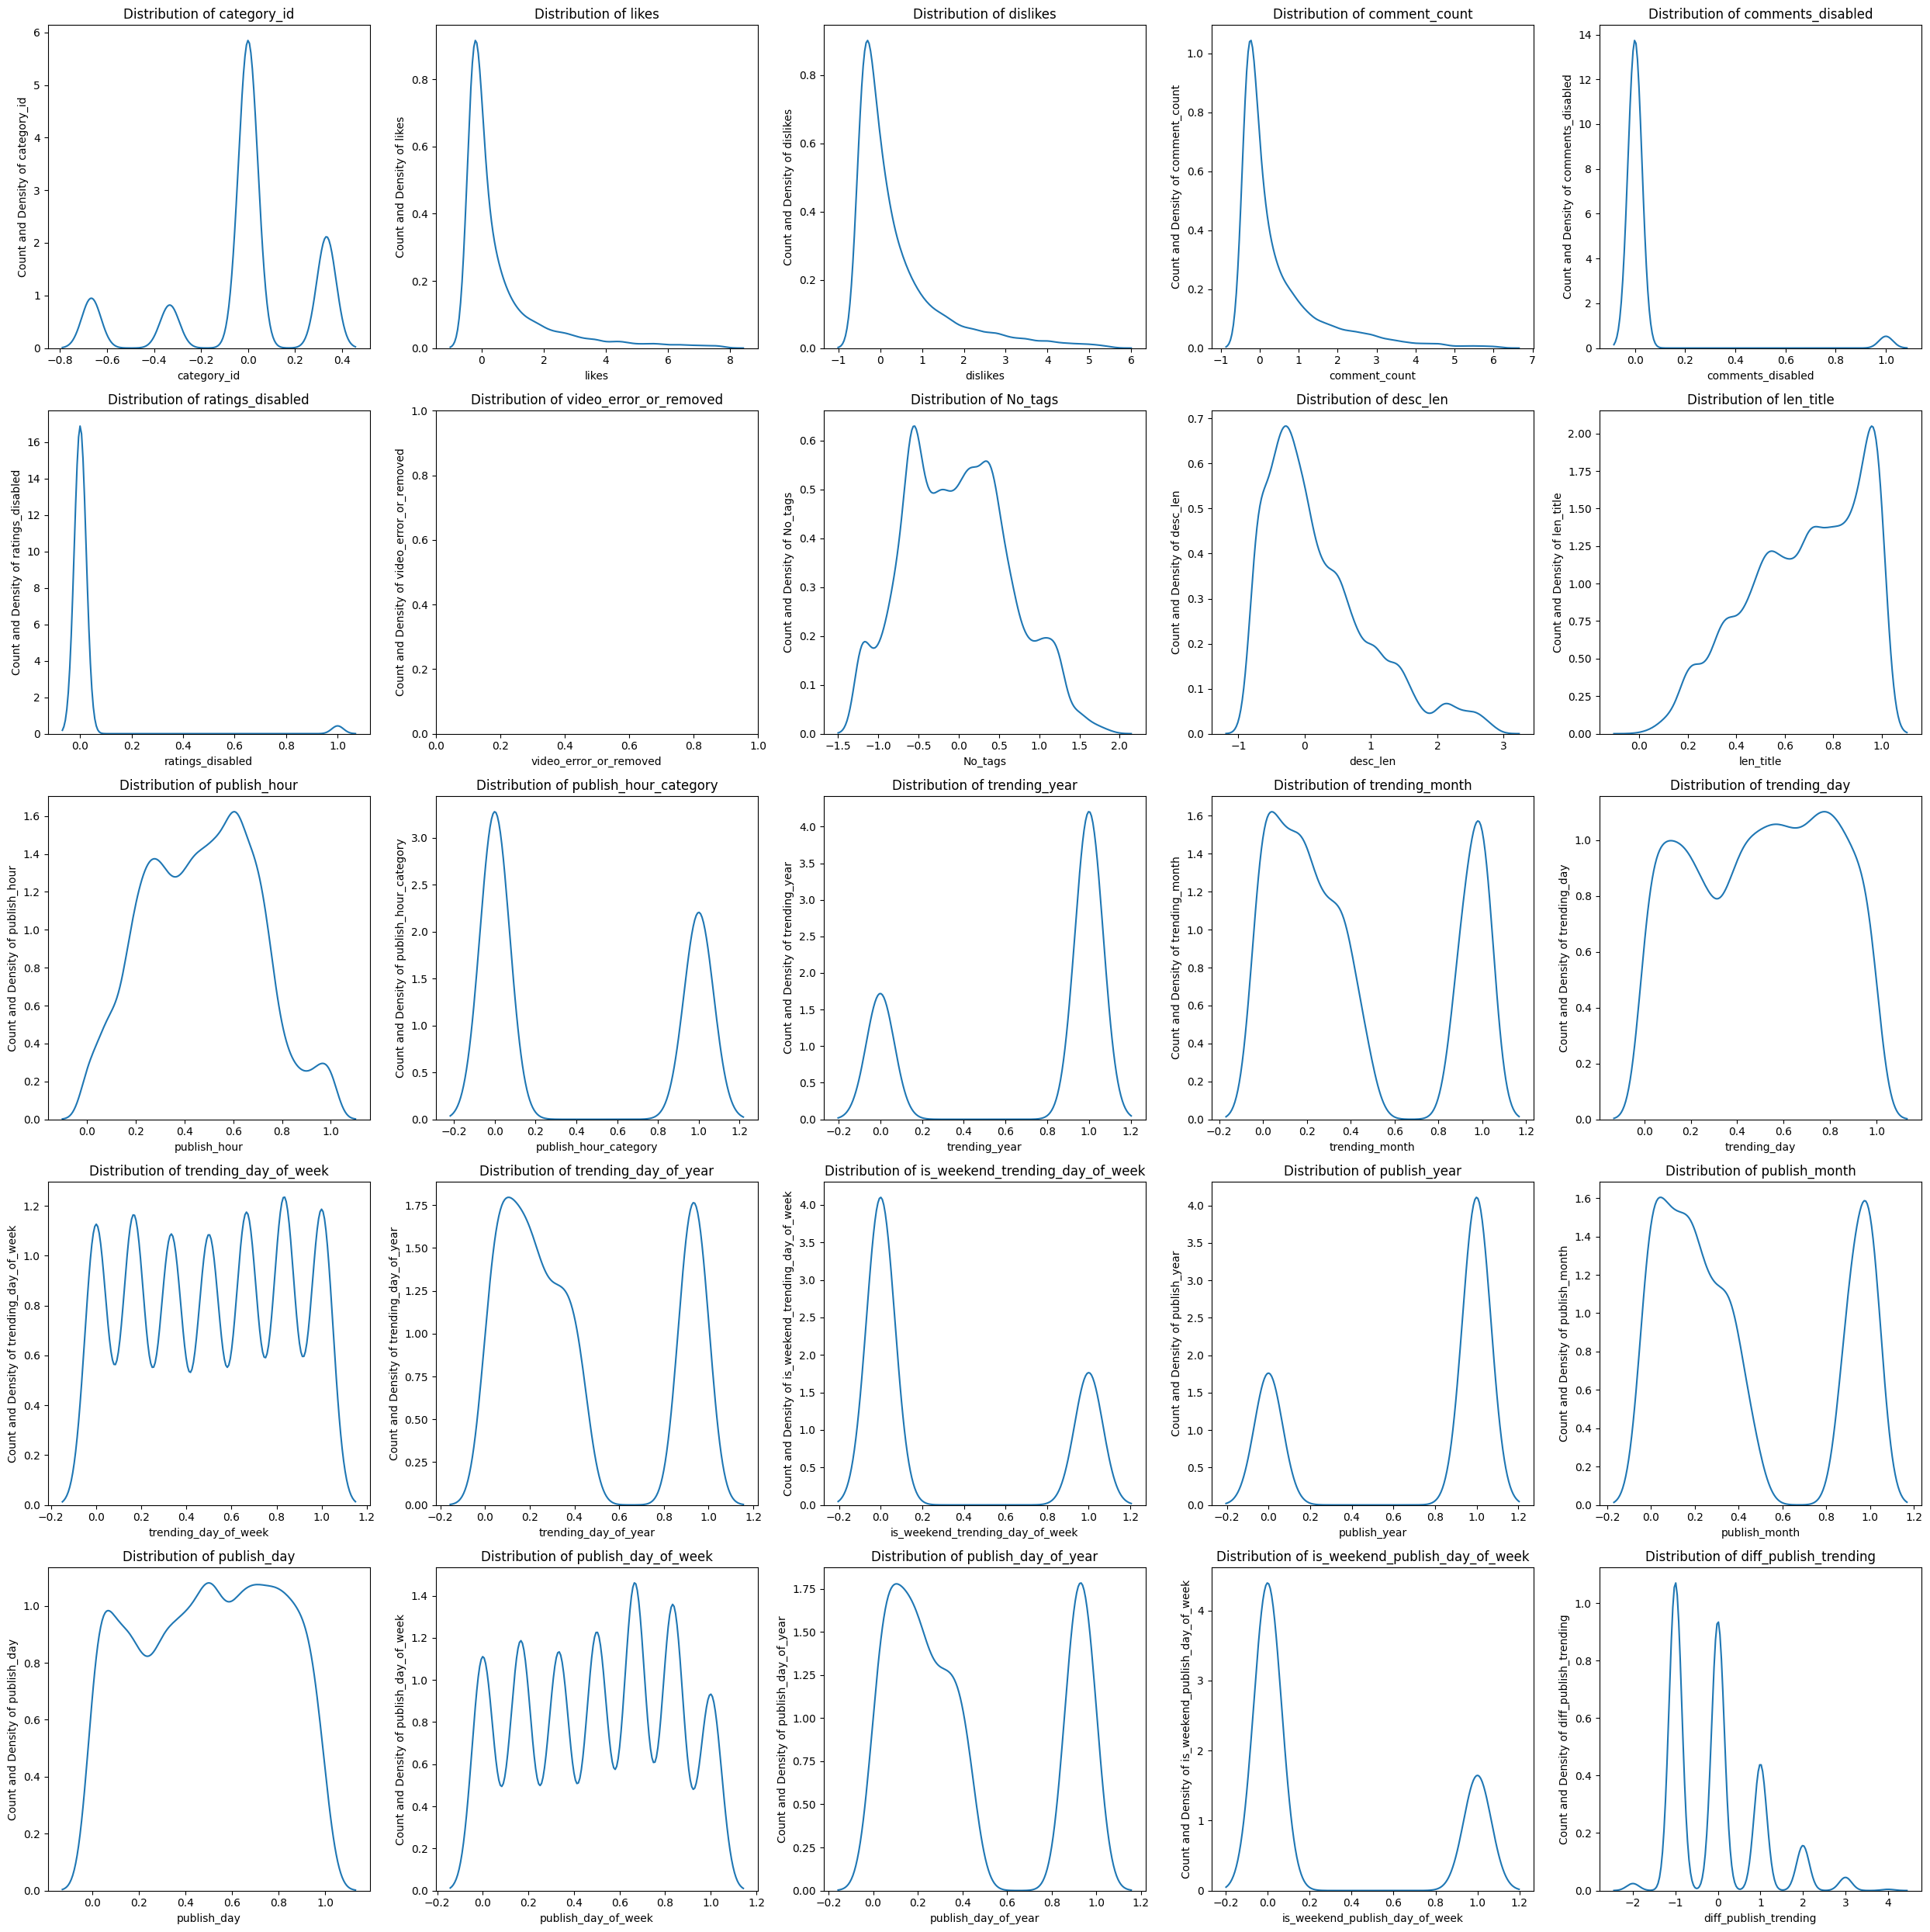

In [ ]:
def plot_distribution(data, plot_type='kde'):
    """
    Function to plot the distribution of features in the dataset.

    Parameters:
    data (DataFrame): The dataset containing the features to plot.
    plot_type (str): The type of plot to use ('kde' or 'hist').
    """
    fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25,25))
    axes = axes.flatten()

    for i in range(len(data.columns)):
        if plot_type == 'kde':
            sns.kdeplot(data=data, ax=axes[i], x=data.columns[i])
        elif plot_type == 'hist':
            sns.histplot(data=data, ax=axes[i], x=data.columns[i], kde=True)
        axes[i].set_title(f'Distribution of {data.columns[i]}')
        axes[i].set_ylabel(f'Count and Density of {data.columns[i]}')
        axes[i].set_xlabel(f'{data.columns[i]}')

    # Remove the last subplot if there are fewer features than subplots
    if len(data.columns) < len(axes):
        for j in range(len(data.columns), len(axes)):
            fig.delaxes(axes[j])

    plt.tight_layout()

# Example usage:
plot_distribution(x_train, plot_type='kde')

# **STAGE 3 : MODELLING AND EVALUATION**

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

def evaluate_model(X, y, model, cv=5):
    """
    Evaluate the regression model using cross-validation.

    Args:
        X (np.ndarray): Features for prediction.
        y (np.ndarray): Target variable.
        model: Regression model instance.
        cv (int): Number of cross-validation folds.

    Returns:
        dict: Dictionary of evaluation metrics (MAE, RMSE, MAPE, R2).
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    predictions = cross_val_predict(model, X, y, cv=kf)

    # Metrics
    mae = mean_absolute_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    mape = np.mean(np.abs((y - predictions) / y)) * 100
    r2 = r2_score(y, predictions)

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def train_and_evaluate_tfidf(X, y, model=None, test_size=0.2, cv=5):
    """
    Train and evaluate a regression model using TF-IDF features.

    Args:
        X (np.ndarray): TF-IDF feature matrix.
        y (np.ndarray): Target variable.
        model: Regression model instance. Defaults to RandomForestRegressor.
        test_size (float): Proportion of test data. Defaults to 0.2.
        cv (int): Number of cross-validation folds. Defaults to 5.

    Returns:
        dict: Evaluation metrics on the test set.
    """
    if model is None:
        model = RandomForestRegressor(random_state=42)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Cross-validation evaluation
    metrics = evaluate_model(X, y, model, cv=cv)
    print("Cross-Validation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    # Evaluate on test set
    y_pred = model.predict(X_test)
    test_metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
        "R2": r2_score(y_test, y_pred),
    }

    print("\nTest Set Metrics:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.4f}")

    return model, test_metrics

# Example Usage
# Assuming tfidf_features is the feature matrix from TF-IDF and processed_df is the original DataFrame
target_column = 'views'  # Replace with your target column name
y = processed_df[target_column].values  # Target variable
X = tfidf_features  # TF-IDF feature matrix

# Train and evaluate the model
final_model, test_metrics = train_and_evaluate_tfidf(
    X=X,
    y=y,
    model=RandomForestRegressor(random_state=42),
    test_size=0.2,
    cv=5
)

## Train Regression Models

In [ ]:
#Check the amount of training and test data
print(f'Rows of training data : {len(x_train)}')
print(f'Rows of test data : {len(x_test)}')

Rows of training data : 13937
Rows of test data : 9769


In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(x_train, y_train)

Ridge()

In [ ]:
# Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(x_train, y_train)

Lasso()

In [ ]:
# Elastic Net Regression
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(x_train, y_train)

ElasticNet()

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

DecisionTreeRegressor()

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
# Support Vector Regression
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train, y_train)

SVR()

In [ ]:
# Boosting : AdaBoost Regression
from sklearn.ensemble import AdaBoostRegressor
ab = AdaBoostRegressor()
ab.fit(x_train, y_train)

AdaBoostRegressor()

In [ ]:
# Boosting : XGBoost Regression
from xgboost import XGBRegressor
xg = XGBRegressor()
xg.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Neural Network
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor()
nn.fit(x_train, y_train)

MLPRegressor()

## Model Evaluation

In [ ]:
#Import metrics score that will be evalueated
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_validate

#Function for model evaluation metrics score
def eval_regression(model):
  y_pred = model.predict(x_test)
  y_pred_train = model.predict(x_train)

  # print('MAE (train): ' + str(mean_absolute_error(y_test, y_pred_train)))
  print('MAE (test): ' + str(mean_absolute_error(y_test, y_pred)))

  # print('RMSE (train): ' + str(mean_squared_error(y_train, y_pred_train, squared=False)))
  print('RMSE (test): ' + str(mean_squared_error(y_test, y_pred, squared=False)))

  # print('MAPE (train): ' + str(mean_absolute_percentage_error(y_train, y_pred_train)))
  print('MAPE (test): ' + str(mean_absolute_percentage_error(y_test, y_pred)))

  # print('R2 (train): ' + str(r2_score(y_train, y_pred_train)))
  print('R2 (test): ' + str(r2_score(y_test, y_pred)))

  #Cross Validation
  score = cross_validate(model, x_train, y_train, cv=5, scoring='r2', return_train_score=True) #scoring change based on what metrics we want to validate (usually choose the main performance metric)
  print('R2 Score (crossval train): '+ str(score['train_score'].mean()))
  print('R2 Score (crossval test): '+ str(score['test_score'].mean()))


In [ ]:
#Printing metrics score for all models to compare

#Linear Regression
print('\nEvaluate LinearRegression')
eval_regression(lr)

#Ridge Regressor
print('\nEvaluate RidgeRegression')
eval_regression(ridge)

#Lasso Regressor
print('\nEvaluate LassoRegression')
eval_regression(lasso)

#Elastic Net Regressor
print('\nEvaluate ElasticNetRegression')
eval_regression(elasticnet)

#Decision Tree Regressor
print('\nEvaluate DecisionTreeRegressor')
eval_regression(dt)

#Random Forest Regressor
print('\nEvaluate RandomForestRegressor')
eval_regression(rf)

#Support Vector Regressor
print('\nEvaluate SVR')
eval_regression(svr)

#AdaBoost Regressor
print('\nEvaluate AdaBoostRegressor')
eval_regression(ab)

#XGBoost Regressor
print('\nEvaluate XGBRegressor')
eval_regression(xg)

#MLP Regression
print('\nEvaluate MLPRegressor')
eval_regression(nn)


Evaluate LinearRegression
MAE (test): 242389602910.41248
RMSE (test): 13831753681896.908
MAPE (test): 113116.94551269794
R2 (test): -16981065825758.291
R2 Score (crossval train): 0.5356381561583997
R2 Score (crossval test): 0.533728293616891

Evaluate RidgeRegression
MAE (test): 654077.0066645213
RMSE (test): 6992424.720902723
MAPE (test): 0.9667473145453032
R2 (test): -3.339763390576035
R2 Score (crossval train): 0.5344551743024104
R2 Score (crossval test): 0.5328318198153765

Evaluate LassoRegression
MAE (test): 654133.00998328
RMSE (test): 6993427.5364945745
MAPE (test): 0.9669702480558776
R2 (test): -3.341008250445273
R2 Score (crossval train): 0.5344592354032187
R2 Score (crossval test): 0.5328315247229936

Evaluate ElasticNetRegression
MAE (test): 596666.9483959482
RMSE (test): 4753518.031818222
MAPE (test): 1.041772949379225
R2 (test): -1.0055834822438707
R2 Score (crossval train): 0.48553546806584313
R2 Score (crossval test): 0.48547502272889564

Evaluate DecisionTreeRegressor

### Feature Importance in Linear Models

In [ ]:
# Flatten the coefficient arrays
lr_coef = pd.Series(lr.coef_.flatten())
ridge_coef = pd.Series(ridge.coef_.flatten())
lasso_coef = pd.Series(lasso.coef_.flatten())
elasticnet_coef = pd.Series(elasticnet.coef_.flatten())

# Creating a DataFrame with coefficients
linear_model_coef = pd.DataFrame({'lr_coef': lr_coef,
                                  'ridge_coef': ridge_coef,
                                  'lasso_coef': lasso_coef,
                                  'elasticnet_coef': elasticnet_coef})

# Add feature names to the DataFrame
linear_model_coef['Feature'] = x_train.columns

# Set 'Feature' as the index
linear_model_coef.set_index('Feature', inplace=True)

# Display coef DataFrame
display(linear_model_coef)

,lr_coef,ridge_coef,lasso_coef,elasticnet_coef
Feature,,,,
category_id,-2.421087e+04,-24248.193941,-24279.024676,-3935.085420
likes,5.509443e+04,54722.615089,54729.542693,48670.189595
dislikes,1.955945e+05,196503.187083,196537.704625,124050.058657
comment_count,-4.180052e+04,-41975.618039,-42004.770122,3005.492612
comments_disabled,-4.362259e+04,-43623.324956,-43864.095721,3161.511460
ratings_disabled,2.431372e+05,244149.188646,244936.128016,8275.814591
video_error_or_removed,-7.892992e+14,0.000000,0.000000,0.000000
No_tags,1.789552e+04,17520.904646,17527.991151,10669.778807
desc_len,1.976427e+04,19595.118132,19592.254340,13652.846619


# Summary of Models Generated by Various Machine Learning Algorithms

Experiment was conducted on the models below :

1. Linear Regression (with regularization : Ridge, Lasso, and Elastic Net)
2. Decision Tree Regression
3. Random Forest Regression
4. Support Vector Regression
5. Gradient Boosting Regression (AdaBoost and XGBoost)
6. Multi-Layer Perceptron (MLP) Regression

From all of the models, the best results were obtained by:

- **Random Forest Regression**
- **XGBoost Regression**

Therefore, hyperparameter tuning can be applied to these two models to slightly improve their results (for other models that also have decent performance, experiments will be conducted if there is time and additional resources available).

## Feature Importances from Regression Models

In [ ]:
#Function for model feature importance score
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=x.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('Score')
    plt.ylabel('Feature')
    plt.title('Feature importance score')

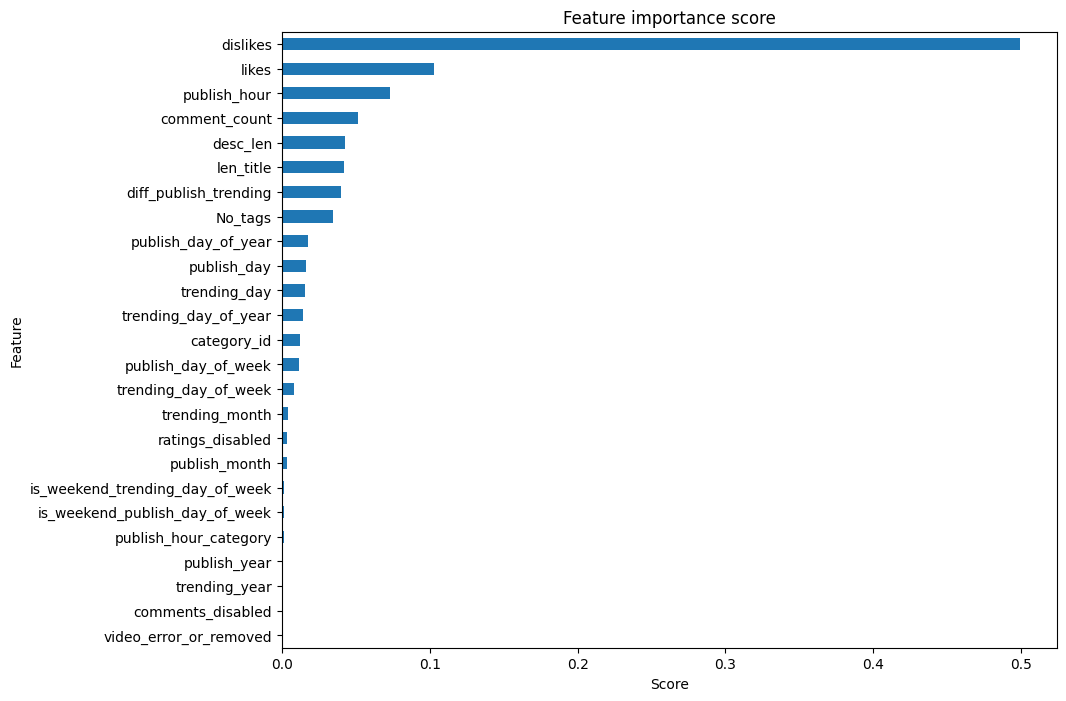

In [ ]:
# Feature importance in random forest
show_feature_importance(rf)

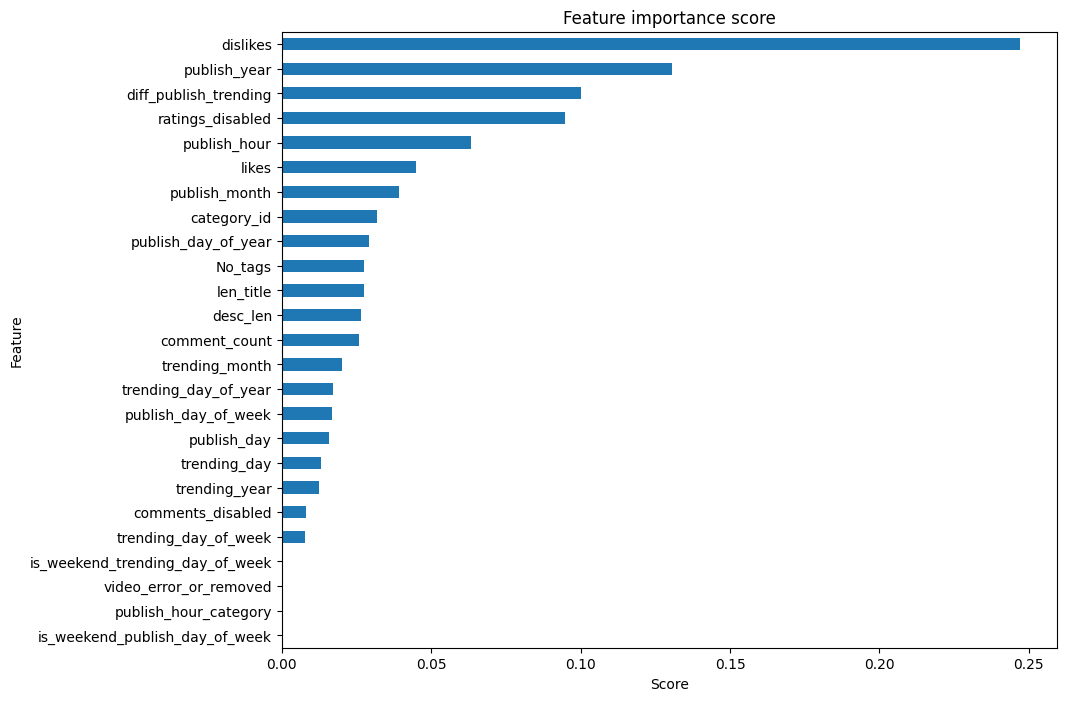

In [ ]:
# Feature importance in XGB
show_feature_importance(xg)

## Hyperparameter Tuning

In [ ]:
#Function for best hyperparameters found during the tuning process
def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

### Hyperparameter Tuning For Random Forest Regression

<b>Commonly tuned hyperparameters in Random Forest:</b> (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html'>Sklearn Random Forest Documentation</a>)

- n_estimators: the number of trees to be built in the forest.
- max_samples: the maximum number of samples to be drawn from the total training set for building each tree (after the bootstrap process).

The remaining hyperparameters are the same as in Decision Trees:

- criterion: the method used to measure impurity in features (gini, entropy). This is for classification; for regression, it's different. It determines which feature becomes the root/node (squared_error, poisson).
- max_depth: the maximum depth of each tree to prevent overfitting.
- min_sample_split: the minimum number of samples required at a node to create a new leaf (to avoid having too few samples, which can lead to overfitting).
- min_sample_leaf: the minimum number of samples required in a leaf for the leaf to be formed (to avoid having too few samples, which can lead to overfitting).
- ccp_alpha: if the cost/error of a leaf/subtree is greater than ccp_alpha, that subtree will be pruned, minimizing the error/variance of the model.

In [ ]:
# Hyperparameter Tuning for random forest
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Initiate hyperparameters used and their values
n_estimators = [int(x) for x in np.linspace(50, 180, 5)]
criterion = ['squared_error', 'poisson']
max_depth = [int(x) for x in np.linspace(50, 180, 5)]
min_samples_split = [int(x) for x in np.linspace(2, 10, 2)]
min_samples_leaf = [int(x) for x in np.linspace(2, 10, 2)]

#Collecting all hyperparameters into a single dictionary
hyperparameters = dict(n_estimators=n_estimators,
                       criterion=criterion,
                       max_depth=max_depth,
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf)

#Initiate tuned model
rf = RandomForestRegressor()
# rf_tuned = GridSearchCV(dt, hyperparameters, cv=5, scoring='r2')
rf_tuned = RandomizedSearchCV(rf, hyperparameters, scoring='r2', cv=5, error_score='raise')
rf_tuned.fit(x_train, y_train)

#Tuned model evaluation
eval_regression(rf_tuned)

MAE (test): 670593.8343174031
RMSE (test): 3197034.1717275316
MAPE (test): 0.5930682597912154
R2 (test): 0.09279588941552341
R2 Score (crossval train): 0.924999059161212
R2 Score (crossval test): 0.7119895851724807


In [ ]:
# Best hyperparameter in random forest
show_best_hyperparameter(rf_tuned)

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'poisson', 'max_depth': 50, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 180, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [ ]:
# Retrieving the best hyperparameters for random forest (similar to show_best_hyperparameter code before, but only shows the ones that we used)
best_params = rf_tuned.best_params_
best_params

{'n_estimators': 180,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_depth': 50,
 'criterion': 'poisson'}

In [ ]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # n_estimators
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # max_depth
# # param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_split
# param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_leaf

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = RandomForestRegressor(min_samples_leaf=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : min_sample_leaf | Random Forest') # Change based on what hyperparameter that we used
# plt.ylabel('R2 Score')
# plt.xlabel('min_sample_leaf') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()

### Hyperparameter Tuning For XGBoost Regression

<b>Commonly tuned hyperparameters in XGBoost:</b>  (<a href='https://xgboost.readthedocs.io/en/latest/parameter.html'>XGBoost Documentation</a>)

- <b>Tree architecture-related:</b>
    - max_depth: the maximum depth of the tree to prevent overfitting.
    - min_child_weight: the minimum weight (or the number of samples if the total weight equals 1) a node should have to create a new leaf (to avoid having too few, causing overfitting).
    - gamma: the minimum loss/error reduction required to make a new leaf.
    - tree_method: the method XGBoost uses to build a tree. The algorithm we are learning is tree_method = exact. Other references can be found <a href='https://xgboost.readthedocs.io/en/latest/treemethod.html'>here</a>.

- <b>Boosting process subsampling:</b> Instead of using the entire training data in each iteration, we can use a sample in each iteration.
    - subsample: how much of the row samples to be used for sampling at each step. 1 for all rows.
    - colsample_bytree: how many features to be used. 1 for all features.

- <b>Control learning rate:</b>
    - eta: the step size for updating the feature weight in XGBoost, value range: 0-1. Smaller eta provides more fine-grained corrections but requires more boosting iterations.
        - In sklearn, the hyperparameter name is learning_rate.

- <b>Regularization in XGBoost:</b>
    - lambda: the regularization term on L2 norm.
    - alpha: the regularization term on L1 norm.

- <b>Learning task in XGBoost:</b>
    - objective: the objective function used, such as calculating error in regression.
    - eval_metric: evaluation metrics used on the validation data (e.g., rmse, mae, auc).
    - seed: random state.

- <b>Others:</b>
    - scale_pos_weight: if the data is imbalanced, this parameter is used to adjust the weight of each label.
    
- <b>Other parameters for model checking and debugging:</b>
    - verbose: to display detailed log information during the model training. 0: no messages; 1: display warnings only; 2: display info (deprecated examples); 3: debug: detailed training information for the model.

In [ ]:
#Hyperparameter tuning for xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Initiate hyperparameters used and their values
max_depth = [int(x) for x in np.linspace(50, 180, 5)]
min_child_weight = [int(x) for x in np.linspace(1, 20, 11)]
gamma = [float(x) for x in np.linspace(0, 3, num = 11)]
tree_method = ['auto', 'exact', 'approx']

colsample_bytree = [float(x) for x in np.linspace(0, 1, 11)]
eta = [float(x) for x in np.linspace(0, 1, num = 100)]

# lambda = [float(x) for x in np.linspace(0, 1, 11)]
alpha = [float(x) for x in np.linspace(0, 1, 11)]

#Collecting all hyperparameters into a single dictionary
hyperparameters = dict(max_depth=max_depth,
                       min_child_weight=min_child_weight,
                       gamma=gamma,
                       tree_method=tree_method,
                       colsample_bytree=colsample_bytree,
                       eta=eta,
                       alpha=alpha)

#Initiate tuned model
xg = XGBRegressor()
# xg_tuned = GridSearchCV(xg, hyperparameters, cv=5, scoring='r2')
xg_tuned = RandomizedSearchCV(xg, hyperparameters, scoring='r2', cv=5, error_score='raise')
xg_tuned.fit(x_train,y_train)

# Evaluation
eval_regression(xg_tuned)

MAE (test): 680878.7643495533
RMSE (test): 3215731.649601106
MAPE (test): 0.6477532415489926
R2 (test): 0.08215350697335533
R2 Score (crossval train): 0.9942632554300392
R2 Score (crossval test): 0.7622192522244393


In [ ]:
# Best hyperparameter in xgb
show_best_hyperparameter(xg_tuned)

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.5, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 2.6999999999999997, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 115, 'max_leaves': None, 'min_child_weight': 18, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'exact', 'validate_parameters': None, 'verbosity': None, 'eta': 0.08080808080808081, 'alpha': 0.2}


In [ ]:
# Retrieving the best hyperparameters for xgb (similar to show_best_hyperparameter code before, but only shows the ones that we used)
best_params = xg_tuned.best_params_
best_params

{'tree_method': 'exact',
 'min_child_weight': 18,
 'max_depth': 115,
 'gamma': 2.6999999999999997,
 'eta': 0.08080808080808081,
 'colsample_bytree': 0.5,
 'alpha': 0.2}

In [ ]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(5, 20, 11)] #max_depth
# # param_values = [int(x) for x in np.linspace(1, 20, 11)] #min_child_weight
# # param_values = [float(x) for x in np.linspace(0, 3, num = 11)] #gamma
# # param_values = ['auto', 'exact', 'approx'] #tree_method
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #colsample_bytree
# # param_values = [float(x) for x in np.linspace(0, 1, 100)] #eta
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #lambda
# param_values = [float(x) for x in np.linspace(0, 1, 11)] #alpha

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = XGBRegressor(alpha=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : alpha | XGB') # Change based on what hyperparameter that we used
# plt.ylabel('AUC')
# plt.xlabel('alpha') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()

## Comparison of Results Before and After Hyperparameter Tuning

<b>Evaluate RandomForestRegressor</b>

- Before Hyperparameter Tuning
    - MAE (test): 664766.6023503576
    - RMSE (test): 3176146.0151437307
    - MAPE (test): 0.6269118547067823
    - R2 (test): 0.10461178826553719
    - R2 Score (crossval train): 0.958699637383497
    - R2 Score (crossval test): 0.7106541738473096

- After Hyperparameter Tuning
    - MAE (test): 670593.8343174031
    - RMSE (test): 3197034.1717275316
    - MAPE (test): 0.5930682597912154
    - R2 (test): 0.09279588941552341
    - R2 Score (crossval train): 0.924999059161212
    - R2 Score (crossval test): 0.7119895851724807

<b>Evaluate XGBRegressor</b>

- Before Hyperparameter Tuning
    - MAE (test): 674435.1305398261
    - RMSE (test): 3199200.2948880275
    - MAPE (test): 0.6215205310783862
    - R2 (test): 0.09156613617964471
    - R2 Score (crossval train): 0.9672637928829507
    - R2 Score (crossval test): 0.7652375612499716

- After Hyperparameter Tuning
    - MAE (test): 680878.7643495533
    - RMSE (test): 3215731.649601106
    - MAPE (test): 0.6477532415489926
    - R2 (test): 0.08215350697335533
    - R2 Score (crossval train): 0.9942632554300392
    - R2 Score (crossval test): 0.7622192522244393

Further tuning need to be done, and we can also experiment with other combination of features in training